# Limpieza y preparación de datos — RE/MAX CABA

Este notebook realiza la limpieza, validación y preparación de la base
obtenida mediante el scraper de RE/MAX.

La base original se encuentra en `data/raw/` y no se modifica durante
este proceso. El resultado de la limpieza se almacena en `data/processed/`.

El objetivo es construir el universo de departamentos usados en venta
en CABA que será utilizado posteriormente para el análisis descriptivo,
la construcción de comparables y la identificación de oportunidades.

**Dependencias:** las funciones de auditoría, registro y aplicación de excepciones están en `src/limpieza.py`; los patrones de texto, en `src/patrones.py`; las funciones de diagnóstico (validación de ambientes, faltantes y outliers), en `src/diagnostico.py`; y las correcciones manuales por aviso, en `data/excepciones_manuales.csv`.

**Salidas:** `data/processed/remax_deptos_limpio.csv` (base analítica) y `data/processed/registro_limpieza.csv` (registro de cada paso de limpieza).

In [1]:
# 1. ENTORNO E IMPORTS

import os

REPO_URL = "https://github.com/DTosoratti/tp-analitica-descriptiva-real-estate.git"
REPO_DIR = "/content/tp-analitica-descriptiva-real-estate"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    !git -C {REPO_DIR} pull

%cd {REPO_DIR}

import pandas as pd
import numpy as np
from pathlib import Path
import gdown
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox, chi2

from src.limpieza import (
    resumen_calidad, auditar_categorica, auditar_numericas,
    auditar_reglas, casos_regla, buscar_patron, texto_propiedad,
    excluir, modificar, tabla_registro,
    cargar_excepciones, aplicar_excepciones,
)
from src.patrones import PATRONES, clasificar_estado, AMENITIES_BINARIAS, BBOX_CABA
from src.diagnostico import (
    ambientes_desde_titulo, normalizar_etiqueta,
    diagnostico_faltantes, logit_faltantes, detectar_outliers,
)

Cloning into 'tp-analitica-descriptiva-real-estate'...
remote: Enumerating objects: 173, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 173 (delta 78), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (173/173), 30.88 MiB | 9.29 MiB/s, done.
Resolving deltas: 100% (78/78), done.
/content/tp-analitica-descriptiva-real-estate


In [2]:
# 2. CARGA DE LA BASE RAW

FILE_ID = "1EapNHaHFCOYzIgedcWNqcLYoFHDkF3QE"

RAW_DIR = Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = RAW_DIR / "remax_caba_propiedades.csv"

# Descargar solamente si todavía no existe
if not RAW_PATH.exists():
    gdown.download(
        id=FILE_ID,
        output=str(RAW_PATH),
        quiet=False
    )

print("RAW existe:", RAW_PATH.exists())
print("Ruta:", RAW_PATH)

Downloading...
From: https://drive.google.com/uc?id=1EapNHaHFCOYzIgedcWNqcLYoFHDkF3QE
To: /content/tp-analitica-descriptiva-real-estate/data/raw/remax_caba_propiedades.csv
100%|██████████| 36.6M/36.6M [00:00<00:00, 101MB/s]

RAW existe: True
Ruta: data/raw/remax_caba_propiedades.csv


In [3]:
# 3. CARGA DE DATOS

df = pd.read_csv(RAW_PATH)

print("Dimensiones de la base raw:", df.shape)
display(df.head())

Dimensiones de la base raw: (17023, 29)


,ID,ID_Entidad,Operacion,Tipo_Propiedad,Titulo,Descripcion,Fecha_Publicacion,Antiguedad,Apto_Credito,Amenities,...,Superficie_Total_m2,Superficie_Cubierta_m2,Direccion,Barrio,Ubicacion,Latitud,Longitud,Estado,ID_Interno,Link
0,659301,6490000a-c53f-4150-8700-ac60a22f3e12,sale,departamento_estandar,VENTA DPTO 2 AMBIENTES - VILLA URQUIZA,VENTA DEPARTAMENTO 2 AMBIENTES - VILLA URQUIZA...,NaN,36.0,True,NaN,...,43.1,43.1,Rómulo Naón 2700,Villa Urquiza,"Villa Urquiza, Capital Federal",-34.564467,-58.475397,active,420251318-73,https://www.remax.com.ar/listings/venta-dpto-2...
1,659299,94e305ad-f3f8-4eee-af38-df5e4566b70b,sale,departamento_estandar,DEPARTAMENTO 2 AMBIENTES A ESTRENAR NUÑEZ,2 AMBIENTES A ESTRENAR | 53 M² | APTO PROFESIO...,NaN,0.0,False,Electricidad | Agua | Gas | Ascensor | Dormito...,...,53.0,53.0,Avenida Cabildo 4000,Nuñez,"Nuñez, Capital Federal",-34.546124,-58.470159,active,421031011-151,https://www.remax.com.ar/listings/departamento...
2,659297,a4a7257d-4082-4b20-95c0-0939d8c2b7b6,sale,departamento_estandar,VENTA DOS AMBIENTES REFACCIONADO EN SAN NICOLAS,VENTA 2 AMBIENTES REFACCIONADO EN SAN NICOLÁS ...,NaN,51.0,False,Dormitorio | Comedor | Baño | Cocina | Living ...,...,40.0,40.0,Carlos Pellegrini 700,San Nicolás,"San Nicolás, Capital Federal",-34.599678,-58.381079,active,181735-34,https://www.remax.com.ar/listings/venta-dos-am...
3,659296,6a59d9c8-1714-4ee3-a4dd-e008e4fcbce4,sale,departamento_estandar,Venta 2 amb con Patio,2 ambientes en planta baja con Patio\n\nCómodo...,NaN,46.0,True,Electricidad | Agua | Gas | Internet | Teléfon...,...,45.0,45.0,Avenida de los Corrales 6700,Mataderos,"Mataderos, Capital Federal",-34.664229,-58.501972,active,420251309-267,https://www.remax.com.ar/listings/venta-2-amb-...
4,659293,04298ff7-ab5b-4fad-85d7-19ed48b4d671,sale,terrenos_y_lotes,"VENTA LOTE 8,40m x34 m VENDIBLES 1750 M2 BALVA...",OPORTUNIDAD ! VENTA LOTE EN BALVANERA VENDIBL...,NaN,NaN,False,Electricidad,...,290.0,0.0,General Urquiza 100,Balvanera,"Balvanera, Capital Federal",-34.612080,-58.410336,active,421141029-209,https://www.remax.com.ar/listings/venta-lote-8...


### Fecha de corte y cobertura

**Fecha de corte.** La base corresponde a una única corrida completa del extractor sobre RE/MAX, realizada aproximadamente el 26 de septiembre de 2026 (según la fecha de creación del archivo de la extracción). Como la fuente no informa la fecha de publicación de los avisos (`Fecha_Publicacion` llega vacía), la fecha de corte es la de la extracción: la base describe el stock publicado en ese momento y no permite analizar la evolución temporal de los precios.

**Cobertura geográfica.** La extracción se restringió a Capital Federal mediante el filtro de la propia fuente. La cobertura efectiva se controla con las coordenadas de cada aviso y, en la etapa de ingeniería de variables, con la asignación a los barrios oficiales.

### Posibles sesgos de la fuente

- **Una sola red inmobiliaria.** RE/MAX no representa toda la oferta de CABA. Su participación puede variar entre barrios y segmentos, por lo que la base describe la oferta de esta red y no el mercado completo.
- **Precios publicados.** Los precios son de oferta y no de cierre. La brecha entre ambos no se observa en los datos.
- **Información declarada por el anunciante.** Superficies, antigüedad, estado y ubicación se informan con fines comerciales. En la etapa de ingeniería de variables se observó, por ejemplo, que algunos avisos se etiquetan con el barrio vecino de mayor valor.
- **Fallas de captura.** Una parte de los avisos no tiene descripción, antigüedad ni apto crédito porque falló la consulta al endpoint de detalle (se analiza en el paso 10).
- **Foto de un momento.** Con una sola corrida, la base sobrerrepresenta los avisos que permanecen publicados más tiempo: los que se venden rápido tienen menos probabilidad de aparecer en una captura puntual.

Además, se guarda en `data/raw/` una muestra de 500 avisos de la base raw, con la misma estructura que la base completa, que se aloja en Google Drive por su tamaño.

In [4]:
# 3.1 FECHA DE CORTE, COBERTURA Y MUESTRA DE LA BASE RAW

FECHA_CORTE = "2026-09-26"

print("Fecha de corte (extracción):", FECHA_CORTE)
print("Avisos en la base raw:", len(df))

# Cobertura geográfica según las coordenadas
print("\nRango de latitud: ", round(df["Latitud"].min(), 4), "a", round(df["Latitud"].max(), 4))
print("Rango de longitud:", round(df["Longitud"].min(), 4), "a", round(df["Longitud"].max(), 4))

dentro_caba = (
    df["Latitud"].between(*BBOX_CABA["lat"]) & df["Longitud"].between(*BBOX_CABA["lon"])
)
print(f"Avisos dentro del rango aproximado de CABA: {dentro_caba.mean() * 100:.2f}%")
print("Etiquetas de ubicación distintas:", df["Barrio"].nunique())

# Muestra representativa de la base raw (la base completa se aloja en Drive)
RUTA_MUESTRA = RAW_DIR / "remax_caba_propiedades_muestra.csv"
df.sample(n=500, random_state=42).to_csv(RUTA_MUESTRA, index=False)
print(f"\nMuestra guardada: {RUTA_MUESTRA} (500 avisos, misma estructura que la base completa)")

Fecha de corte (extracción): 2026-09-26
Avisos en la base raw: 17023

Rango de latitud:  -80.1873 a -31.4752
Rango de longitud: -96.8782 a -55.7117
Avisos dentro del rango aproximado de CABA: 99.95%
Etiquetas de ubicación distintas: 75

Muestra guardada: data/raw/remax_caba_propiedades_muestra.csv (500 avisos, misma estructura que la base completa)


**Resultado.** La base raw contiene 17.023 avisos extraídos aproximadamente el 26 de septiembre de 2026. El 99,95% de los avisos tiene coordenadas dentro del rango geográfico aproximado de la Ciudad. Los rangos extremos de latitud y longitud (por ejemplo, una latitud de −80°, correspondiente a la Antártida) se deben a menos de diez avisos con errores de geolocalización, no a propiedades fuera de la Ciudad. Muchos de esos avisos se excluyen después por los filtros de alcance, y los que permanecen en la base limpia se identifican y se tratan al asignar el barrio oficial en el notebook de ingeniería de variables.

La fuente informa 75 etiquetas de ubicación distintas, más que los 48 barrios oficiales de la Ciudad, porque incluyen subzonas y denominaciones informales. Por eso la ubicación se reasigna a partir de las coordenadas y de los límites oficiales.

Se guardó una muestra de 500 avisos en `data/raw/remax_caba_propiedades_muestra.csv`, con la misma estructura que la base completa.

## 4. Auditoría inicial de calidad

Antes de aplicar filtros o transformaciones se realiza una auditoría general de la
base raw. El objetivo es identificar valores faltantes, tipos de datos, cantidad
de valores únicos y posibles duplicados sin modificar todavía las observaciones.

Para evitar chequeos repetidos por variable, la auditoría se centraliza en una
función reutilizable.

In [5]:
print("Filas:", len(df))
print("Columnas:", df.shape[1])
print("IDs duplicados:", df["ID"].duplicated().sum())

display(resumen_calidad(df))

Filas: 17023
Columnas: 29
IDs duplicados: 0


,Tipo,Nulos,Nulos_%,Unicos
Fecha_Publicacion,float64,17023,100.00,0
Amenities,object,3911,22.97,10902
Expensas,float64,1237,7.27,1652
Antiguedad,float64,598,3.51,135
Precio_m2_Cubierto,float64,524,3.08,12297
Descripcion,object,116,0.68,16602
Apto_Credito,object,116,0.68,2
Precio_m2_Total,float64,3,0.02,13081
Moneda_Expensas,object,2,0.01,2
ID,int64,0,0.00,17023


La extracción contiene distintos tipos de propiedades publicadas en RE/MAX.
Como el análisis se concentra en departamentos usados en venta en CABA, primero
se inspeccionan las categorías disponibles antes de aplicar los filtros.

In [6]:
display(auditar_categorica(df, "Operacion"))
display(auditar_categorica(df, "Tipo_Propiedad"))

,Operacion,Cantidad,Porcentaje
0,sale,17023,100.0


,Tipo_Propiedad,Cantidad,Porcentaje
0,departamento_estandar,8804,51.72
1,ph,1931,11.34
2,departamento_monoambiente,1451,8.52
3,casa,886,5.20
4,cochera,634,3.72
5,departamento_semipiso,597,3.51
6,terrenos_y_lotes,559,3.28
7,oficina,457,2.68
8,local,457,2.68
9,departamento_duplex,344,2.02


### Primeras observaciones
* La extracción corresponde exclusivamente a propiedades en venta (`sale`), por lo que no es necesario aplicar un filtro adicional por tipo de operación.

* Como el proyecto se concentra en departamentos, se excluyen otros tipos de
propiedad como casas, PH, cocheras, terrenos, oficinas y locales.

* RE/MAX clasifica los departamentos en distintas categorías. Para evitar perder
observaciones válidas, se consideran todas las tipologías correspondientes a
departamentos y no únicamente `departamento_estandar`.

* La variable `Tipo_Propiedad_Original` conserva la clasificación original de
RE/MAX, mientras que `Tipo_Propiedad` se homogeneiza como `departamento` para
representar el universo general de análisis.

Los filtros se realizan sobre la base procesada y no sobre la base raw, de modo
que la extracción original permanece disponible para auditoría.

In [7]:
df_limpio = df.copy()

### Fecha de publicación

La variable `Fecha_Publicacion` presenta un 100% de valores faltantes debido a
que la fuente consultada no informa este dato.

No se realiza imputación, ya que no existe información suficiente para
reconstruir la fecha original de publicación de cada aviso. La variable se
conserva para documentar esta limitación de la fuente.

In [8]:
print("Fecha_Publicacion — porcentaje de faltantes:",
      round(df_limpio["Fecha_Publicacion"].isna().mean() * 100, 2), "%")

Fecha_Publicacion — porcentaje de faltantes: 100.0 %


## 5. Filtro de alcance: tipología

Se aplica el primer filtro de alcance según el criterio descripto en las primeras observaciones: se conservan todas las subcategorías de departamento y se excluyen las demás tipologías.

A partir de este paso, cada exclusión o modificación sobre `df_limpio` queda anotada en un registro de limpieza. El registro guarda el paso, el criterio aplicado, la cantidad de registros afectados y el tamaño de la base antes y después. Al final del notebook permite reconstruir el recorrido completo desde la base raw hasta la base analítica.

In [9]:
# 5. FILTRO DE ALCANCE: TIPOLOGÍA

registro = []

df_limpio["Tipo_Propiedad_Original"] = df_limpio["Tipo_Propiedad"]

mask_no_departamento = ~df_limpio["Tipo_Propiedad"].str.startswith(
    "departamento_", na=False
)

df_limpio = excluir(
    df_limpio,
    mask_no_departamento,
    paso="Alcance: tipología",
    criterio="Se excluyen tipologías que no son departamento (casa, PH, cochera, terreno, etc.)",
    registro=registro,
)

df_limpio["Tipo_Propiedad"] = "departamento"

display(tabla_registro(registro))
display(auditar_categorica(df_limpio, "Tipo_Propiedad_Original"))

,Paso,Tipo,Criterio,Registros_afectados,Filas_antes,Filas_despues
0,Alcance: tipología,Exclusión,Se excluyen tipologías que no son departamento...,5358,17023,11665


,Tipo_Propiedad_Original,Cantidad,Porcentaje
0,departamento_estandar,8804,75.47
1,departamento_monoambiente,1451,12.44
2,departamento_semipiso,597,5.12
3,departamento_duplex,344,2.95
4,departamento_piso,322,2.76
5,departamento_loft,59,0.51
6,departamento_triplex,53,0.45
7,departamento_penthouse,35,0.30


**Resultado del filtro.** Se excluyeron 5.358 registros (31,5% de la base raw) que no corresponden a departamentos, y la base pasa de 17.023 a 11.665 avisos. Dentro del universo de departamentos predominan las unidades estándar (75,5%) y los monoambientes (12,4%). Las demás subcategorías tienen una participación menor.

Se conservan también las subcategorías triplex (53) y penthouse (35). Aunque son departamentos, representan segmentos poco frecuentes y de mayor valor, por lo que podrían aparecer como valores extremos en precio o superficie. No se excluyen en esta etapa: se evaluarán en el análisis de outliers para distinguir entre errores de carga y segmentos genuinos del mercado.

## 6. Filtro de alcance: stock usado

El análisis se concentra en stock usado, porque el objetivo es comparar propiedades existentes entre sí (subvaluación) y evaluar casos de refacción (flipping). Las publicaciones en pozo, preventa, en construcción o a estrenar responden a otra lógica de precio y quedan fuera del alcance.

La fuente no tiene un campo que indique si una propiedad es nueva, así que se identifica combinando la antigüedad con el texto del aviso:

- **Antigüedad negativa:** el año de construcción informado es posterior al actual, lo que indica una obra en desarrollo.
- **Antigüedad 0 o faltante con texto de pozo/estreno:** una antigüedad de 0 por sí sola no alcanza, porque puede ser un error de carga en una propiedad usada. Por eso se exige además evidencia en el título o la descripción.
- **Título de emprendimiento, pozo o estreno.**

En la misma etapa se detectan dos errores de carga observados en la exploración previa: publicaciones de **alquiler** cargadas como venta y **PH** clasificados como departamento.

Antes de excluir se revisan muestras de cada grupo. En particular, la expresión "a estrenar" también aparece en avisos de departamentos reciclados. Excluirlos por error eliminaría justamente el grupo de comparación necesario para el análisis de flipping, así que esos casos se revisan por separado.

In [10]:
# 6. ALCANCE: STOCK USADO — DETECCIÓN

ant = df_limpio["Antiguedad"]
nuevo_texto = buscar_patron(df_limpio, PATRONES["nuevo_fuerte"], "texto")
nuevo_titulo = buscar_patron(df_limpio, PATRONES["nuevo_titulo"], "titulo")
reciclado = buscar_patron(df_limpio, PATRONES["reciclada"], "texto")

criterios_nuevo = {
    "Antigüedad negativa": ant < 0,
    "Antigüedad 0 + texto pozo/estreno": (ant == 0) & nuevo_texto,
    "Antigüedad faltante + texto pozo/estreno": ant.isna() & nuevo_texto,
    "Título de pozo/emprendimiento/estreno": nuevo_titulo,
}

mask_nuevo = pd.concat(criterios_nuevo, axis=1).any(axis=1)

mask_alquiler = (
    buscar_patron(df_limpio, PATRONES["alquiler_descripcion"], "descripcion")
    & ~buscar_patron(df_limpio, PATRONES["venta_titulo"], "titulo")
)

mask_ph = (
    buscar_patron(df_limpio, PATRONES["ph_titulo"], "titulo")
    & buscar_patron(df_limpio, PATRONES["ph_fuerte"], "texto")
)

resumen_alcance = pd.DataFrame({
    "Casos": {**{k: int(v.sum()) for k, v in criterios_nuevo.items()},
              "NUEVO (unión de criterios)": int(mask_nuevo.sum()),
              "Nuevo y también menciona reciclado": int((mask_nuevo & reciclado).sum()),
              "Alquiler cargado como venta": int(mask_alquiler.sum()),
              "PH cargado como departamento": int(mask_ph.sum())}
})
display(resumen_alcance)

cols = ["ID", "Titulo", "Antiguedad", "Barrio", "Precio_Valor"]

print("\n Muestra: detectados como NUEVOS")
display(df_limpio.loc[mask_nuevo, cols].sample(min(15, mask_nuevo.sum()), random_state=42))

print("\nNuevos que también mencionan RECICLADO (posibles falsos positivos)")
display(df_limpio.loc[mask_nuevo & reciclado, cols])

print("\n Posibles ALQUILERES")
display(df_limpio.loc[mask_alquiler, cols + ["Descripcion"]])

print("\n Posibles PH")
display(df_limpio.loc[mask_ph, cols])

,Casos
Antigüedad negativa,239
Antigüedad 0 + texto pozo/estreno,1219
Antigüedad faltante + texto pozo/estreno,43
Título de pozo/emprendimiento/estreno,1341
NUEVO (unión de criterios),1989
Nuevo y también menciona reciclado,12
Alquiler cargado como venta,6
PH cargado como departamento,53



 Muestra: detectados como NUEVOS


,ID,Titulo,Antiguedad,Barrio,Precio_Valor
10036,602253,VENTA MONOAMBIENTE CON AMENITIES BELGRANO,0.0,Belgrano,121053.0
14741,537860,VENTA EN POZO 3 AMB- C/AMENITIES-SAAVEDRA,-2.0,Saavedra,349440.0
7169,622024,Departamento 2 Amb Venta Belgrano R Amenities,0.0,Belgrano R,225000.0
888,655016,VTA ESTRENAR MONOAMB AMENITIES EXC UBI S. TELMO,0.0,Monserrat,83000.0
6342,627098,VENTA MONOAMBIENTE A ESTRENAR VILLA URQUIZA,0.0,Villa Urquiza,98000.0
7297,621054,DPTO MONOAMB VENTA PALERMO. OPORTUNIDAD INVERS...,0.0,Palermo,130200.0
13552,563277,VENTA DEPARTAMENTO 2 AMB C/BALCÓN TERRAZA- PAL...,0.0,Palermo,182900.0
15183,525191,Venta mono amb 39m2 balcon parrilla Villa Crespo,0.0,Villa Crespo,108000.0
16037,473067,Venta Departamento 3 Amb Desarrollo Villa Urquiza,0.0,Villa Urquiza,248318.0
10909,594732,Venta depto de 2 amb a estrenar Belgrano,0.0,Belgrano,177572.0



Nuevos que también mencionan RECICLADO (posibles falsos positivos)


,ID,Titulo,Antiguedad,Barrio,Precio_Valor
290,658004,DEPARTAMENTO 2 AMB. REFACC. A ESTRENAR C/PATIO PB,59.0,Palermo,140000.0
719,655743,Venta departamento 2 amb Retiro refacc a estrenar,36.0,Retiro,118000.0
4643,636275,Venta depto 2 ambientes refaccionado patio Pal...,0.0,Palermo,90000.0
5812,629903,VENTA DEPARTAMENTO A ESTRENAR RECOLETA,66.0,San Nicolás,57500.0
6113,628327,PREVENTA DEPARTAMENTO 2 AMBIENTES - VILLA DEVOTO,0.0,Villa Devoto,138000.0
6114,628324,PREVENTA DEPARTAMENTO 3 AMBIENTES - VILLA DEVOTO,0.0,Villa Devoto,215000.0
6971,623289,MONOAMBIENTE MONSERRAT APTO PROF. ÚLTIMAS UNID,0.0,Monserrat,78999.0
7086,622556,PISO 5 AMBIENTES VENTA RETIRO RECICLADO A ESTR...,60.0,Retiro,520000.0
8908,610259,4Amb con Balcón en Recoleta como a estrenar,46.0,Recoleta,257000.0
9371,606746,VENTA BARRACAS 2 Ambientes a estrenar c/balcón 2B,0.0,Barracas,113000.0



 Posibles ALQUILERES


,ID,Titulo,Antiguedad,Barrio,Precio_Valor,Descripcion
258,658136,Monoambiente /balcon-pileta-parrilla-Gym-laundry,8.0,Almagro,600000.0,Excelente monoambiente con pileta y parrilla....
4688,636075,Depto 3 Ambientes Apto Profesional con Balcón,47.0,San Nicolás,99000.0,Ubicado sobre la emblemática Avenida Rivadavia...
7180,621944,Monoambiente Recoleta,61.0,Recoleta,53000.0,DEPARTAMENTO 1 AMBIENTE EN VENTA EN RECOLETA ....
10419,599109,Departamento 3 amb. con cochera APTO CREDITO,15.0,Caballito,223000.0,"Semipiso al Frente / Piso 6 / Caballito, CABA ..."
11547,588949,Alquiler Tres ambientes en Villa Crespo,50.0,Villa Crespo,127000.0,"Departamento tres ambientes en alquiler, piso ..."
14991,531634,"Tres Ambientes en French y Araoz, Parque Las H...",82.0,Palermo,169000.0,Venta - 3 Ambientes con Gran Baulera en Recole...



 Posibles PH


,ID,Titulo,Antiguedad,Barrio,Precio_Valor
219,658315,VENTA PH 4 AMBIENTES CON TERRAZA QUINCHO EN DE...,66.0,Villa Devoto,190000.0
387,657564,"PH. 3 AMB. Con Terraza, Balcones y Parrilla.",21.0,Villa Urquiza,170000.0
402,657504,PH 3 AMBIENTES VENTA COLEGIALES OPORTUNIDAD,16.0,Colegiales,139999.0
909,654920,DEPTO TIPO PH EN PB VENTA 2 AMB V GRAL MITRE P...,65.0,Villa General Mitre,99900.0
1014,654587,VENTA PH 2 AMBIENTES EN ALMAGRO,50.0,Almagro,59900.0
1248,653577,Venta PH RECICLADO 3 amb patio toilette Caballito,60.0,Almagro,210000.0
1304,653266,Venta PH 3 ambientes Palermo Hollywood,66.0,Palermo Hollywood,83000.0
1615,651910,Venta PH 4 dormitorios patio + terraza - Liniers,50.0,Liniers,115000.0
2176,649055,EN VENTA PH 3 AMB CON COCHERA SIN EXP - VILLA ...,36.0,Villa Real,230000.0
2729,646392,PH en Núñez 3300 Primer Piso – Saavedra,57.0,Saavedra,175000.0


### Revisión de los casos detectados

**PH cargados como departamento.** Los 53 avisos detectados corresponden efectivamente a PH: el título lo indica explícitamente ("Venta PH", "departamento tipo PH"). Se excluyen por coherencia con el filtro de tipología, ya que el PH es un producto distinto del departamento (pocas unidades por lote, entrada independiente, patios propios, sin amenities) y mezclarlo distorsionaría los comparables de precio.

**Propiedades nuevas.** La revisión muestra que el criterio basado en el título genera falsos positivos: avisos de departamentos con 40 a 60 años de antigüedad que se publicitan como "a estrenar" porque fueron reciclados a nuevo. Excluirlos eliminaría parte del segmento "reciclado", que es necesario para estimar el valor posterior a una refacción. Por eso se revisa la distribución de la antigüedad entre los avisos detectados por el título, para definir un umbral.

**Alquileres.** La regla de detección es poco precisa: varios avisos marcados mencionan "venta" en la descripción o "apto crédito", que es propio de una compraventa. Como son pocos casos, se revisan manualmente y los alquileres confirmados se registran en la tabla de excepciones, en lugar de aplicar una regla automática.

In [11]:
# 6.1 EXCLUSIÓN DE PH CARGADOS COMO DEPARTAMENTO

df_limpio = excluir(
    df_limpio,
    mask_ph,
    paso="Error de carga: PH",
    criterio="El título indica PH y el texto lo confirma con un patrón fuerte",
    registro=registro,
)

In [12]:
# 6.2 REVISIÓN DEL CRITERIO DE TÍTULO SEGÚN ANTIGÜEDAD

ant = df_limpio["Antiguedad"]
nuevo_titulo = buscar_patron(df_limpio, PATRONES["nuevo_titulo"], "titulo")

tramos = pd.cut(
    ant[nuevo_titulo],
    bins=[-np.inf, -0.5, 0.5, 2, 5, 10, np.inf],
    labels=["Negativa", "0", "1 a 2", "3 a 5", "6 a 10", "Más de 10"],
)
print("Antigüedad de los avisos detectados como nuevos por el título:")
display(tramos.value_counts(dropna=False).sort_index().rename("Casos").to_frame())

print("\n--- Detectados por título con antigüedad mayor a 2 años ---")
display(
    df_limpio.loc[nuevo_titulo & (ant > 2), ["ID", "Titulo", "Antiguedad", "Barrio", "Precio_Valor"]]
    .sort_values("Antiguedad")
)

Antigüedad de los avisos detectados como nuevos por el título:


,Casos
Antiguedad,
Negativa,117
0,694
1 a 2,387
3 a 5,58
6 a 10,12
Más de 10,13
NaN,59



--- Detectados por título con antigüedad mayor a 2 años ---


,ID,Titulo,Antiguedad,Barrio,Precio_Valor
2900,645650,2 AMB EN CABALLITO CON BALCÓN Y COCHERA A ESTR...,3.0,Caballito,270000.0
3289,643706,DEPTO 2 AMB A ESTRENAR CON BALCON Y AMENITIES,3.0,Palermo,139000.0
2589,647141,VENTA DEPTO 3 AMB A ESTRENAR C/COCHERA CABALLITO,3.0,Caballito,334000.0
4904,635009,Monoambiente a estrenar con cochera Villa Ortuzar,3.0,Villa Ortuzar,86000.0
3471,642731,VENTA DEPTO 2 AMBIENTES SAN CRISTOBAL A ESTRENAR,3.0,San Cristobal,137500.0
...,...,...,...,...,...
16872,246650,Venta Depto 2 ambientes a estrenar en Montserrat,51.0,Monserrat,115000.0
15711,498938,VENTA DEPARTAMENTO 3 AMBIENTES A ESTRENAR LUMI...,52.0,Recoleta,174900.0
290,658004,DEPARTAMENTO 2 AMB. REFACC. A ESTRENAR C/PATIO PB,59.0,Palermo,140000.0
7086,622556,PISO 5 AMBIENTES VENTA RETIRO RECICLADO A ESTR...,60.0,Retiro,520000.0


In [13]:
# 6.3 LECTURA DE LOS POSIBLES ALQUILERES

mask_alquiler = (
    buscar_patron(df_limpio, PATRONES["alquiler_descripcion"], "descripcion")
    & ~buscar_patron(df_limpio, PATRONES["venta_titulo"], "titulo")
)

print("\n--- Posibles alquileres: fragmento de la descripción ---")
for _, fila in df_limpio.loc[mask_alquiler].iterrows():
    desc = str(fila["Descripcion"])
    fragmento = re.search(r".{0,150}alquil.{0,150}", desc, flags=re.IGNORECASE)
    print(f"\nID {fila['ID']} | USD {fila['Precio_Valor']:,.0f} | {fila['Titulo']}")
    print("   ...", fragmento.group(0) if fragmento else desc[:300], "...")


--- Posibles alquileres: fragmento de la descripción ---

ID 658136 | USD 600,000 | Monoambiente /balcon-pileta-parrilla-Gym-laundry
   ... Se alquilan cocheras en el edificio----- ...

ID 636075 | USD 99,000 | Depto 3 Ambientes Apto Profesional con Balcón
   ... Actualmente se alquila por dia por Airbn ...

ID 621944 | USD 53,000 | Monoambiente Recoleta
   ... Se alquila con renta (contrato vence en marzo del 2028) ...

ID 599109 | USD 223,000 | Departamento 3 amb. con cochera APTO CREDITO
   ... - Edificio con encargado medio día. (Dato destacado: la vivienda del encargado se alquila, lo que reduce los gastos comunes). ...

ID 588949 | USD 127,000 | Alquiler Tres ambientes en Villa Crespo
   ... Departamento tres ambientes en alquiler, piso alto ,muy luminoso,  contrafrente. ...

ID 531634 | USD 169,000 | Tres Ambientes en French y Araoz, Parque Las Heras
   ...  departamento combina el encanto de la arquitectura de época con la funcionalidad de una propiedad totalmente eléctrica y 

### Decisiones

**Umbral de antigüedad para el criterio de título.** Entre los avisos detectados como nuevos por el título, la mayoría tiene antigüedad negativa, 0 o de 1 a 2 años, y la frecuencia cae fuertemente a partir de los 5 años. Los casos de 3 a 5 años corresponden a edificios terminados recientemente con unidades sin habitar, que siguen siendo oferta nueva. En cambio, los avisos con más de 5 años de antigüedad (en varios casos entre 40 y 60 años) que dicen "a estrenar" son departamentos reciclados. Por eso, el criterio basado en el título se aplica solo cuando la antigüedad es de hasta 5 años o no está informada. Con este ajuste, 25 avisos que antes se excluían se conservan como stock usado.

**Alquileres.** La lectura de las descripciones mostró que la regla automática no es confiable. En cinco de los seis casos, "se alquila" se refiere a que la propiedad está alquilada al momento de la venta (renta temporaria, contrato vigente) o a otras unidades del edificio (cocheras, vivienda del encargado). Solo el aviso 588949 corresponde efectivamente a un alquiler, por lo que se registra en la tabla de excepciones manuales en lugar de usar una regla.

Durante la revisión se detectó además un monoambiente publicado a USD 600.000 (ID 658136), un valor incoherente para ese tipo de unidad. Se evaluará en la etapa de outliers.

In [14]:
# 6.4 EXCLUSIÓN DE PROPIEDADES NUEVAS

UMBRAL_ANTIG_TITULO = 5

ant = df_limpio["Antiguedad"]
nuevo_texto = buscar_patron(df_limpio, PATRONES["nuevo_fuerte"], "texto")
nuevo_titulo = buscar_patron(df_limpio, PATRONES["nuevo_titulo"], "titulo")

criterios_nuevo = {
    "Antigüedad negativa": ant < 0,
    "Antigüedad 0 + texto pozo/estreno": (ant == 0) & nuevo_texto,
    "Antigüedad faltante + texto pozo/estreno": ant.isna() & nuevo_texto,
    f"Título pozo/estreno + antigüedad ≤ {UMBRAL_ANTIG_TITULO} o sin dato":
        nuevo_titulo & ((ant <= UMBRAL_ANTIG_TITULO) | ant.isna()),
}

mask_nuevo = pd.concat(criterios_nuevo, axis=1).any(axis=1)

print("Casos por criterio (un aviso puede cumplir más de uno):")
display(pd.Series({k: int(v.sum()) for k, v in criterios_nuevo.items()}, name="Casos").to_frame())

print("Conservados como usados por el ajuste del umbral:",
      int((nuevo_titulo & (ant > UMBRAL_ANTIG_TITULO) & ~mask_nuevo).sum()))

df_limpio = excluir(
    df_limpio,
    mask_nuevo,
    paso="Alcance: stock usado",
    criterio=(f"Pozo, preventa, en construcción o a estrenar "
              f"(título con antigüedad ≤ {UMBRAL_ANTIG_TITULO} años o sin dato)"),
    registro=registro,
)

display(tabla_registro(registro))

Casos por criterio (un aviso puede cumplir más de uno):


,Casos
Antigüedad negativa,239
Antigüedad 0 + texto pozo/estreno,1218
Antigüedad faltante + texto pozo/estreno,43
Título pozo/estreno + antigüedad ≤ 5 o sin dato,1315


Conservados como usados por el ajuste del umbral: 25


,Paso,Tipo,Criterio,Registros_afectados,Filas_antes,Filas_despues
0,Alcance: tipología,Exclusión,Se excluyen tipologías que no son departamento...,5358,17023,11665
1,Error de carga: PH,Exclusión,El título indica PH y el texto lo confirma con...,53,11665,11612
2,Alcance: stock usado,Exclusión,"Pozo, preventa, en construcción o a estrenar (...",1963,11612,9649


**Resultado.** Se excluyeron 53 PH clasificados como departamento y 1.963 avisos de propiedades nuevas (pozo, preventa, en construcción o a estrenar), que representan el 16,9% de los departamentos. La base de stock usado queda conformada por 9.649 avisos, el 56,7% de la extracción original.

El ajuste del umbral de antigüedad permitió conservar 25 departamentos reciclados que, con el criterio original, se habrían excluido por publicitarse como "a estrenar". Esta decisión es relevante para el objetivo del proyecto, porque el segmento de propiedades recicladas funciona como referencia del valor posterior a una refacción.

## 7. Valores imposibles y consistencia entre variables

Antes del análisis de outliers se identifican los valores imposibles o inconsistentes, como precios o superficies iguales a cero, superficie cubierta mayor que la total o cantidades de ambientes nulas. Estos casos no son valores atípicos sino errores de carga, y deben resolverse antes de calcular estadísticos de dispersión, porque los distorsionarían.

La auditoría se hace en tres niveles:

1. **Rango de cada variable numérica:** nulos, ceros, negativos y percentiles extremos.
2. **Valores de relleno:** se revisan los valores más frecuentes de cada variable para detectar códigos que puedan representar datos no informados (por ejemplo, 1 o 999).
3. **Reglas de consistencia entre variables:** relaciones que deben cumplirse por definición, como que la superficie cubierta no supere la total o que el precio por m² informado coincida con el calculado.

In [15]:
# 7. VALORES IMPOSIBLES Y CONSISTENCIA — AUDITORÍA

cols_numericas = [
    "Precio_Valor", "Expensas", "Superficie_Total_m2", "Superficie_Cubierta_m2",
    "Precio_m2_Total", "Precio_m2_Cubierto", "Ambientes", "Dormitorios",
    "Baños", "Antiguedad",
]

faltan = [c for c in cols_numericas if c not in df_limpio.columns]
if faltan:
    print("Columnas no encontradas (revisar nombre):", faltan)
cols_numericas = [c for c in cols_numericas if c in df_limpio.columns]

In [16]:
# 7.1 Rango de cada variable
print("Rango de las variables numéricas:")
display(auditar_numericas(df_limpio, cols_numericas))

Rango de las variables numéricas:


,Nulos,Ceros,Negativos,Min,P01,P25,Mediana,P75,P99,Max
Variable,,,,,,,,,,
Precio_Valor,0,0,0,20000.00,39948.00,82000.00,120000.00,184900.00,899040.00,6300000.00
Expensas,0,1056,0,0.00,0.00,106000.00,180000.00,281697.00,1095200.00,3400000.00
Superficie_Total_m2,0,0,0,14.00,22.00,42.52,60.00,86.98,269.52,38090.00
Superficie_Cubierta_m2,0,1,0,0.00,21.43,38.76,53.00,75.97,226.49,33420.00
Precio_m2_Total,0,0,0,2.89,771.53,1640.50,2067.31,2568.97,5107.65,18750.00
Precio_m2_Cubierto,1,0,0,3.29,875.44,1808.47,2333.33,2928.32,6111.08,21428.57
Ambientes,0,0,0,1.00,1.00,2.00,3.00,3.00,6.00,13.00
Dormitorios,0,1026,0,0.00,0.00,1.00,2.00,2.00,4.00,9.00
Baños,0,0,0,1.00,1.00,1.00,1.00,1.00,3.00,8.00


In [17]:
# 7.2 Valores más frecuentes (posibles valores de relleno)
print("\nCinco valores más frecuentes por variable:")
frecuentes = {
    col: df_limpio[col].value_counts().head(5).index.tolist()
    for col in cols_numericas
}
display(pd.DataFrame(frecuentes).T.rename(columns=lambda i: f"Top {i+1}"))


Cinco valores más frecuentes por variable:


,Top 1,Top 2,Top 3,Top 4,Top 5
Precio_Valor,120000.0,115000.0,110000.0,125000.00,65000.00
Expensas,0.0,200000.0,150000.0,120000.00,180000.00
Superficie_Total_m2,50.0,42.0,40.0,35.00,60.00
Superficie_Cubierta_m2,40.0,50.0,30.0,42.00,45.00
Precio_m2_Total,2500.0,2000.0,1500.0,1666.67,1428.57
Precio_m2_Cubierto,2500.0,2000.0,3000.0,1666.67,1500.00
Ambientes,3.0,2.0,4.0,1.00,5.00
Dormitorios,1.0,2.0,3.0,0.00,4.00
Baños,1.0,2.0,3.0,4.00,5.00
Antiguedad,46.0,56.0,1.0,51.00,0.00


In [18]:
# 7.3 Reglas de consistencia
print("\nCasos que violan cada regla de consistencia:")
display(auditar_reglas(df_limpio))


Casos que violan cada regla de consistencia:


,Casos
Regla,
Cubierta > Total,0
Superficie total <= 0,0
Precio <= 0,0
Ambientes = 0,0
Dormitorios >= Ambientes,699
Antigüedad negativa,0
USD/m² informado != calculado (>1%),0


### Hallazgos y decisiones

**Expensas.** En el universo de departamentos usados no hay valores nulos de expensas, pero 1.056 avisos tienen expensas iguales a 0, que además es el valor más frecuente de la variable. Como un departamento sin expensas es poco habitual, se interpreta que el 0 funciona como código de "dato no informado". Se reemplaza por faltante, excepto en los avisos que mencionan explícitamente que la unidad no paga expensas.

**Antigüedad.** Después de excluir las propiedades nuevas, 287 departamentos usados tienen antigüedad igual a 0, lo cual no es consistente con el universo de análisis. Se reemplaza por faltante.

**Superficie cubierta.** Un aviso tiene superficie cubierta igual a 0. Se reemplaza por faltante, junto con su precio por m² cubierto, que depende de esa superficie.

**Dormitorios y ambientes.** En el mercado argentino la cantidad de ambientes incluye el living, por lo que se espera que los dormitorios sean menos que los ambientes. Hay 699 avisos que no cumplen esta relación. Antes de decidir un tratamiento, se analiza la tabla cruzada entre ambas variables para distinguir errores de carga de diferencias en la forma de informar el dato.

Los valores extremos de superficie y precio por m² no se tratan en este paso, porque corresponden al análisis de outliers.

In [19]:
# 7.4 CORRECCIÓN DE VALORES DE RELLENO E IMPOSIBLES

# Expensas = 0 sin mención de "sin expensas"
sin_expensas = buscar_patron(df_limpio, PATRONES["sin_expensas"], "texto")
mask_exp0 = (df_limpio["Expensas"] == 0) & ~sin_expensas

print("Expensas = 0:", int((df_limpio["Expensas"] == 0).sum()))
print("   de los cuales mencionan 'sin expensas':", int(((df_limpio["Expensas"] == 0) & sin_expensas).sum()))

df_limpio = modificar(
    df_limpio, mask_exp0, "Expensas", np.nan,
    paso="Valores de relleno: expensas",
    criterio="Expensas = 0 sin mención de 'sin expensas' → dato no informado",
    registro=registro,
)

# Antigüedad = 0 en stock usado
mask_ant0 = df_limpio["Antiguedad"] == 0
df_limpio = modificar(
    df_limpio, mask_ant0, "Antiguedad", np.nan,
    paso="Valores de relleno: antigüedad",
    criterio="Antigüedad = 0 en un departamento usado → dato no informado",
    registro=registro,
)

# Superficie cubierta = 0
mask_cub0 = df_limpio["Superficie_Cubierta_m2"] == 0
df_limpio = modificar(
    df_limpio, mask_cub0, "Superficie_Cubierta_m2", np.nan,
    paso="Valor imposible: superficie cubierta",
    criterio="Superficie cubierta = 0",
    registro=registro,
)
df_limpio = modificar(
    df_limpio, mask_cub0, "Precio_m2_Cubierto", np.nan,
    paso="Valor imposible: superficie cubierta",
    criterio="USD/m² cubierto calculado sobre superficie cubierta = 0",
    registro=registro,
)

display(tabla_registro(registro))

Expensas = 0: 1056
   de los cuales mencionan 'sin expensas': 43


,Paso,Tipo,Criterio,Registros_afectados,Filas_antes,Filas_despues
0,Alcance: tipología,Exclusión,Se excluyen tipologías que no son departamento...,5358,17023,11665
1,Error de carga: PH,Exclusión,El título indica PH y el texto lo confirma con...,53,11665,11612
2,Alcance: stock usado,Exclusión,"Pozo, preventa, en construcción o a estrenar (...",1963,11612,9649
3,Valores de relleno: expensas,Modificación (Expensas),Expensas = 0 sin mención de 'sin expensas' → d...,1013,9649,9649
4,Valores de relleno: antigüedad,Modificación (Antiguedad),Antigüedad = 0 en un departamento usado → dato...,287,9649,9649
5,Valor imposible: superficie cubierta,Modificación (Superficie_Cubierta_m2),Superficie cubierta = 0,1,9649,9649
6,Valor imposible: superficie cubierta,Modificación (Precio_m2_Cubierto),USD/m² cubierto calculado sobre superficie cub...,1,9649,9649


In [20]:
# 7.5 REVISIÓN: DORMITORIOS VS AMBIENTES

print("\nTabla cruzada Ambientes × Dormitorios (base completa):")
display(pd.crosstab(df_limpio["Ambientes"], df_limpio["Dormitorios"], margins=True))

viola = df_limpio["Dormitorios"] >= df_limpio["Ambientes"]
print("\nMuestra de avisos con Dormitorios >= Ambientes:")
display(
    df_limpio.loc[viola, ["ID", "Titulo", "Ambientes", "Dormitorios", "Superficie_Cubierta_m2"]]
    .sample(15, random_state=42)
)


Tabla cruzada Ambientes × Dormitorios (base completa):


Dormitorios,0,1,2,3,4,5,6,7,8,9,All
Ambientes,,,,,,,,,,,
1,1021,534,2,0,0,0,0,0,0,0,1557
2,5,2780,21,0,0,0,0,0,0,0,2806
3,0,56,2921,73,2,0,0,0,0,0,3052
4,0,1,109,1596,54,7,0,0,0,0,1767
5,0,1,2,124,198,2,1,0,0,1,329
6,0,1,0,18,52,19,0,1,0,0,91
7,0,0,0,3,11,8,1,0,0,0,23
8,0,0,0,1,3,5,3,2,1,0,15
9,0,0,0,0,0,0,2,0,0,0,2



Muestra de avisos con Dormitorios >= Ambientes:


,ID,Titulo,Ambientes,Dormitorios,Superficie_Cubierta_m2
3805,640743,Venta Departamento Monoambiente c/ balcón Barr...,1,1,32.90
11250,591540,VENTA DEPTO 4 DORMITORIOS BELGRANO - BALCON FTE,4,4,82.06
8996,609754,VENTA DEPARTAMENTO 4 AMBIENTES CABALLITO PATIO,3,3,108.91
3781,640875,VENTA MONOAMBIENTE DIVIDIDO BELGRANO CON BALCON,1,1,32.95
7284,621182,Venta 3 ambientes y dependenc gran patio Recoleta,3,3,77.00
5488,631642,"1 AMB,Fte.Palermo,6to Piso,Vista Embajada,Diseño",1,1,40.00
5847,629736,Monoamb 1 ½ Almagro Cfte Balcón COCHERAS disp...,1,1,47.00
6585,625667,"VENTA MONOAMBIENTE CON BALCÓN | TERRAZAS, PARR...",1,1,31.00
6879,623823,Venta 1 Ambiente Complejo ERRE Amenities Belgr...,1,1,30.21
7906,616808,DEPARTAMENTO 7 AMBIENTES APTO PROFESIONAL BELG...,5,6,114.86


**Resultado.** Se reemplazaron por faltante 1.013 valores de expensas (se conservan con 0 los 43 avisos que indican explícitamente que no pagan expensas), 287 antigüedades iguales a 0 y una superficie cubierta nula. Ninguna de estas correcciones elimina registros: la base se mantiene en 9.649 avisos, y los nuevos faltantes se tratarán en la etapa de valores faltantes.

### Revisión de la relación entre dormitorios y ambientes

La tabla cruzada muestra que la mayoría de los casos con dormitorios iguales o superiores a los ambientes corresponden a **monoambientes cargados con un dormitorio** (534 casos). La muestra revisada confirma que son monoambientes, por título y superficie. El problema es la forma de informar la variable: 1.021 monoambientes tienen 0 dormitorios y 534 tienen 1, para el mismo tipo de unidad. Se unifica el criterio asignando 0 dormitorios a todas las unidades de un ambiente.

En las unidades de dos o más ambientes, la inconsistencia tiene otras causas: la dependencia de servicio informada como dormitorio, o una cantidad de ambientes subestimada respecto de lo que indica el propio título del aviso. Como la cantidad de ambientes es una de las variables que definen el grupo de propiedades comparables, se valida contra el título mediante expresiones regulares, extrayendo la cantidad de ambientes que el aviso declara en su encabezado.

In [21]:
# 7.6 UNIFICACIÓN DE DORMITORIOS EN MONOAMBIENTES

mask_mono_dorm = (df_limpio["Ambientes"] == 1) & (df_limpio["Dormitorios"] > 0)

df_limpio = modificar(
    df_limpio, mask_mono_dorm, "Dormitorios", 0,
    paso="Unificación de criterio: dormitorios",
    criterio="Unidades de 1 ambiente → 0 dormitorios",
    registro=registro,
)

In [22]:
# 7.7 VALIDACIÓN DE AMBIENTES CONTRA EL TÍTULO

amb_titulo = df_limpio["Titulo"].apply(ambientes_desde_titulo)

comparacion = np.select(
    [amb_titulo.isna(), amb_titulo == df_limpio["Ambientes"]],
    ["Sin dato en el título", "Coincide"],
    default="Difiere",
)
comparacion = pd.Series(comparacion, index=df_limpio.index, name="Título vs. Ambientes")

viola = df_limpio["Dormitorios"] >= df_limpio["Ambientes"]

print("Coincidencia entre el título y la variable Ambientes:")
display(pd.crosstab(comparacion, viola.rename("Dormitorios >= Ambientes"), margins=True))

print("\nCasos que difieren (muestra):")
difiere = comparacion == "Difiere"
display(
    df_limpio.loc[difiere, ["ID", "Titulo", "Ambientes", "Dormitorios"]]
    .assign(Ambientes_Titulo=amb_titulo[difiere])
    .sample(min(20, difiere.sum()), random_state=42)
)

Coincidencia entre el título y la variable Ambientes:


Dormitorios >= Ambientes,False,True,All
Título vs. Ambientes,,,
Coincide,8604,130,8734
Difiere,254,21,275
Sin dato en el título,628,12,640
All,9486,163,9649



Casos que difieren (muestra):


,ID,Titulo,Ambientes,Dormitorios,Ambientes_Titulo
2074,649521,VENTA DEPARTAMENTO 5 AMBIENTES LINIERS,4,3,5.0
9304,607218,VENTA MONOAMBIENTE DIVIDO EN RECOLETA AMPLIO,2,1,1.0
11852,585988,Departamento frances venta recoleta 5 ambientes,6,3,5.0
8874,610503,DEPARTAMENTO 5 AMB 2 DORMITORIO Y HAB SERVICIO,4,2,5.0
13152,569524,Departamento 6 amb VENTA Barracas Balcón y Patio,7,4,6.0
13943,555571,VENTA DPTO 2 AMBIENTES C/ ESCRITORIO. SAN NICOLAS,3,1,2.0
15289,519943,Depto 2 ambient y medio Flores al frente c/ ba...,3,1,2.0
12107,582858,"Departamento 4 amb c/dep, balcón aterrazado. 1...",5,4,4.0
15416,513573,Monoambiente divisible - VENTA Almagro,2,1,1.0
9527,605703,DEPARTAMENTO VENTA 6 AMB CON PATIO APTO CREDITO,4,5,6.0


### Resultado de la validación

En el 90,5% de los avisos (8.734) la cantidad de ambientes declarada en el título coincide con la variable `Ambientes`, lo que indica que la variable es confiable en la gran mayoría de los casos. En 640 avisos (6,6%) el título no informa la cantidad de ambientes, y en 275 (2,9%) ambos valores difieren.

La revisión de los casos que difieren muestra que el título no es sistemáticamente más confiable que la variable. En varios avisos la variable incluye ambientes que el título no menciona, como escritorios o dependencias de servicio ("4 amb c/dep" cargado como 5 ambientes). En otros, la variable parece subestimar la cantidad declarada, y también hay títulos que informan rangos ("2/3 amb") o unidades divisibles. Como no hay una dirección consistente del error, no se reemplaza la variable con el valor del título, porque se cambiarían unos errores por otros.

Se adopta un criterio conservador: la variable `Ambientes` se conserva sin cambios y se agregan dos marcas de calidad. `Flag_Ambientes_Dudoso` identifica los avisos en los que el título contradice la variable, y `Flag_Dormitorios_Inconsistente` identifica los que mantienen más dormitorios que ambientes (en su mayoría por dependencias de servicio informadas como dormitorio). Estas marcas permiten excluir esos casos al construir el benchmark de comparables o evaluar su efecto mediante un análisis de sensibilidad. Por su menor confiabilidad, `Dormitorios` no se utilizará como criterio para definir comparables; ese rol queda para `Ambientes`.

In [23]:
# 7.8 MARCAS DE CALIDAD: AMBIENTES Y DORMITORIOS

df_limpio["Ambientes_Titulo"] = amb_titulo

df_limpio["Flag_Ambientes_Dudoso"] = False
df_limpio = modificar(
    df_limpio, comparacion == "Difiere", "Flag_Ambientes_Dudoso", True,
    paso="Marca de calidad: ambientes",
    criterio="La cantidad de ambientes declarada en el título difiere de la variable Ambientes",
    registro=registro,
)

df_limpio["Flag_Dormitorios_Inconsistente"] = False
df_limpio = modificar(
    df_limpio, df_limpio["Dormitorios"] >= df_limpio["Ambientes"],
    "Flag_Dormitorios_Inconsistente", True,
    paso="Marca de calidad: dormitorios",
    criterio="Dormitorios >= Ambientes en unidades de 2 o más ambientes",
    registro=registro,
)

print("Avisos con ambientes dudosos:", int(df_limpio["Flag_Ambientes_Dudoso"].sum()))
print("Avisos con dormitorios inconsistentes:", int(df_limpio["Flag_Dormitorios_Inconsistente"].sum()))

display(tabla_registro(registro))

Avisos con ambientes dudosos: 275
Avisos con dormitorios inconsistentes: 163


,Paso,Tipo,Criterio,Registros_afectados,Filas_antes,Filas_despues
0,Alcance: tipología,Exclusión,Se excluyen tipologías que no son departamento...,5358,17023,11665
1,Error de carga: PH,Exclusión,El título indica PH y el texto lo confirma con...,53,11665,11612
2,Alcance: stock usado,Exclusión,"Pozo, preventa, en construcción o a estrenar (...",1963,11612,9649
3,Valores de relleno: expensas,Modificación (Expensas),Expensas = 0 sin mención de 'sin expensas' → d...,1013,9649,9649
4,Valores de relleno: antigüedad,Modificación (Antiguedad),Antigüedad = 0 en un departamento usado → dato...,287,9649,9649
5,Valor imposible: superficie cubierta,Modificación (Superficie_Cubierta_m2),Superficie cubierta = 0,1,9649,9649
6,Valor imposible: superficie cubierta,Modificación (Precio_m2_Cubierto),USD/m² cubierto calculado sobre superficie cub...,1,9649,9649
7,Unificación de criterio: dormitorios,Modificación (Dormitorios),Unidades de 1 ambiente → 0 dormitorios,536,9649,9649
8,Marca de calidad: ambientes,Modificación (Flag_Ambientes_Dudoso),La cantidad de ambientes declarada en el títul...,275,9649,9649
9,Marca de calidad: dormitorios,Modificación (Flag_Dormitorios_Inconsistente),Dormitorios >= Ambientes en unidades de 2 o má...,163,9649,9649


## 8. Duplicados

La auditoría inicial mostró que no hay identificadores repetidos. Sin embargo, una misma propiedad puede aparecer en más de un aviso con distinto ID: por ejemplo, si la publican dos agentes o si fue dada de baja y vuelta a publicar. Si estos casos no se depuran, una misma unidad tendría un peso doble en el cálculo de los benchmarks de propiedades comparables.

Los duplicados se buscan en cuatro niveles, de mayor a menor exigencia:

1. **Exactos:** coinciden todas las variables salvo los identificadores y el link.
2. **Misma propiedad:** coinciden coordenadas, superficies, ambientes y precio.
3. **Misma propiedad con distinto precio:** coinciden coordenadas, superficies y ambientes, pero no el precio (posible republicación con otro valor).
4. **Misma descripción:** el texto completo del aviso es idéntico.

Hay que tener en cuenta que dos unidades distintas de un mismo edificio pueden compartir coordenadas, superficie y cantidad de ambientes. Por eso, antes de excluir se revisan los casos detectados en cada nivel.

In [24]:
# 8. DUPLICADOS — DETECCIÓN

cols_identificadores = [c for c in ["ID", "ID_Entidad", "ID_Interno", "Link"] if c in df.columns]
cols_contenido = [c for c in df.columns if c not in cols_identificadores]

clave_propiedad = ["Latitud", "Longitud", "Superficie_Total_m2",
                   "Superficie_Cubierta_m2", "Ambientes"]

dup_exacto = df_limpio.duplicated(subset=cols_contenido, keep=False)
dup_propiedad = df_limpio.duplicated(subset=clave_propiedad + ["Precio_Valor"], keep=False)
dup_otro_precio = df_limpio.duplicated(subset=clave_propiedad, keep=False) & ~dup_propiedad
dup_descripcion = (
    df_limpio["Descripcion"].notna()
    & (df_limpio["Descripcion"].str.len() > 100)
    & df_limpio.duplicated(subset=["Descripcion"], keep=False)
)

resumen_dup = pd.DataFrame({
    "Avisos involucrados": {
        "1. Exactos": int(dup_exacto.sum()),
        "2. Misma propiedad (con precio)": int(dup_propiedad.sum()),
        "3. Misma propiedad, distinto precio": int(dup_otro_precio.sum()),
        "4. Misma descripción": int(dup_descripcion.sum()),
    }
})
display(resumen_dup)

cols_ver = ["ID", "Titulo", "Direccion", "Superficie_Total_m2", "Ambientes",
            "Precio_Valor", "Latitud", "Longitud"]

print("\n Muestra nivel 2: misma propiedad con el mismo precio")
display(df_limpio.loc[dup_propiedad, cols_ver]
        .sort_values(["Latitud", "Longitud", "Superficie_Total_m2"]).head(20))

print("\n Muestra nivel 3: misma propiedad con distinto precio ")
display(df_limpio.loc[dup_otro_precio, cols_ver]
        .sort_values(["Latitud", "Longitud", "Superficie_Total_m2"]).head(20))

print("\n Muestra nivel 4: misma descripción ")
display(df_limpio.loc[dup_descripcion, cols_ver + ["Descripcion"]]
        .sort_values("Descripcion").head(20))

,Avisos involucrados
1. Exactos,54
2. Misma propiedad (con precio),190
"3. Misma propiedad, distinto precio",338
4. Misma descripción,174



 Muestra nivel 2: misma propiedad con el mismo precio


,ID,Titulo,Direccion,Superficie_Total_m2,Ambientes,Precio_Valor,Latitud,Longitud
16604,383517,-Departamento 2 AMBIENTES EN FLORESTA,San Nicolas 400,36.00,2,54000.0,-36.297418,-55.711670
16710,350785,-Departamento 2 AMBIENTES EN FLORESTA,San Nicolas 400,36.00,2,54000.0,-36.297418,-55.711670
7398,620307,DEPARTAMENTO VENTA 4 AMB POMPEYA TERRAZA PROPIA,Traful 3500,235.80,4,125000.0,-34.650627,-58.411290
11106,592974,DEPARTAMENTO VENTA 4 AMB PARQUE PATRICIOS TERRAZA,Traful 3500,235.80,4,125000.0,-34.650627,-58.411290
15594,504512,VENTA DEPTO 4 AMBIENTES CON BALCON P PATRICIOS,Avenida Sáenz 300,51.79,4,85000.0,-34.643478,-58.416285
15798,493625,VENTA DEPTO 4 AMBIENTES CON BALCON EN POMPEYA,Avenida Sáenz 300,51.79,4,85000.0,-34.643478,-58.416285
10520,598264,Venta Dto 2amb-Semi Piso-Patio a mts Pza Los A...,Coronel Ramón Lorenzo Falcón 6100,66.00,2,125000.0,-34.640364,-58.513095
16310,439402,Venta Dto 2amb-Semi Piso-Patio a mts Pza Los A...,Coronel Ramón Lorenzo Falcón 6100,66.00,2,125000.0,-34.640364,-58.513095
2650,646791,Venta MONO Flores CENTRO COMERCIAL AVELLANEDA,Avenida Rivadavia 7800,33.16,1,65000.0,-34.632416,-58.475227
5808,629924,Venta monoambiente Flores c balcón y vista abi...,Avenida Rivadavia 7800,33.16,1,65000.0,-34.632416,-58.475227



 Muestra nivel 3: misma propiedad con distinto precio 


,ID,Titulo,Direccion,Superficie_Total_m2,Ambientes,Precio_Valor,Latitud,Longitud
1778,651109,Venta departamento 3 ambientes Barrio Samore,Avenida Castañares 4500,60.00,3,55000.0,-34.665213,-58.471096
15957,480488,Venta departamento 3 ambientes Barrio Samore,Avenida Castañares 4500,60.00,3,49000.0,-34.665213,-58.471096
5027,634298,VENTA DEPARTAMENTO MONOAMBIENTE BARRIO NAON,Andalgalá 1500,38.00,1,85000.0,-34.655336,-58.515641
13515,563789,VENTA DEPARTAMENTO MONOAMBIENTE BARRIO NAON,Andalgalá 1500,38.00,1,75000.0,-34.655336,-58.515641
15278,520643,VENTA DEPARTAMENTO MONOAMBIENTE BARRIO NAON,Andalgalá 1500,38.00,1,70000.0,-34.655336,-58.515641
10514,598301,VENTA Depto 2 amb-DUPLEX-a mts Plza Los Andes,Coronel Ramón Lorenzo Falcón 6100,88.00,2,165000.0,-34.640364,-58.513095
16061,470679,Venta Depto 2 amb DUPLEX-Liniers-a mts Plaza A...,Coronel Ramón Lorenzo Falcón 6100,88.00,2,150000.0,-34.640364,-58.513095
6887,623766,Dpto 2amb venta Chacabuco balcón/parrilla opc/...,Zañartu 1100,38.23,2,85000.0,-34.639511,-58.433532
6889,623764,Dpto 2amb venta Chacabuco balcón/parrilla opc/...,Zañartu 1100,38.23,2,86000.0,-34.639511,-58.433532
8754,611174,Departamento 2 ambientes - Av. Lacarra 337,Avenida Lacarra 300,48.13,2,62463.0,-34.638470,-58.483684



 Muestra nivel 4: misma descripción 


,ID,Titulo,Direccion,Superficie_Total_m2,Ambientes,Precio_Valor,Latitud,Longitud,Descripcion
3250,643893,Apto profesional a refaccionar en Balvanera,Jean Jaures 600,86.00,3,112000.0,-34.601989,-58.407897,\n\nFinanciación privada hasta el 50% del valo...
2845,645896,Apto profesional a refaccionar en Balvanera,Jean Jaures 600,86.00,3,112000.0,-34.601989,-58.407897,\n\nFinanciación privada hasta el 50% del valo...
127,658744,DEPARTAMENTO C/BALCON LUMINOSO AMOBLADO PALERMO,Mario Bravo 1200,47.00,1,125000.0,-34.594849,-58.414611,\nMonoambiente en Palermo ideal inversión Airb...
7395,620348,DEPARTAMENTO C/BALCON LUMINOSO AMOBLADO PALERMO,Mario Bravo 1200,47.00,1,125000.0,-34.594849,-58.414611,\nMonoambiente en Palermo ideal inversión Airb...
8,659287,Venta Monoambiente divisible en Palermo Soho,Paraguay 4700,27.38,1,68000.0,-34.582503,-58.426688,\nVenta departamento monoambiente muy luminoso...
3571,642170,Venta Monoambiente divisible en Palermo Soho,Paraguay 4700,27.38,1,68000.0,-34.582503,-58.426688,\nVenta departamento monoambiente muy luminoso...
4925,634870,VENTA PISO ALTO 6 AMB BELGRANO LUMINOSO BALCON,Echeverría 1900,239.00,6,860000.0,-34.560232,-58.451446,\n​Exclusivo Piso Entero de 6 Ambientes en Pis...
4926,634867,VENTA PISO ALTO 6 AMB BELGRANO LUMINOSO BALCON,Echeverría 1900,239.00,6,860000.0,-34.560232,-58.451446,\n​Exclusivo Piso Entero de 6 Ambientes en Pis...
11528,589073,VENTA DEPTO 3 AMB CON BALC. V. CRESPO APTO CRE...,Avenida Cordoba 4600,65.00,3,153000.0,-34.599121,-58.439702,APTO CREDITO / DEPARTAMENTO 3 AMBIENTES VENTA ...
16134,463805,VENTA DEPTO 3 AMB CON BALC. V. CRESPO APTO CRE...,Avenida Cordoba 4600,65.00,3,153000.0,-34.599121,-58.439702,APTO CREDITO / DEPARTAMENTO 3 AMBIENTES VENTA ...


### Decisiones sobre duplicados

**Niveles 1 y 2.** Los avisos que coinciden en coordenadas, superficies, ambientes y precio corresponden a la misma unidad publicada más de una vez, a veces con diferencias menores en el título (por ejemplo, la misma propiedad etiquetada con dos barrios distintos). Se conserva un único aviso por propiedad, el de ID más alto, bajo el supuesto de que los identificadores de la fuente se asignan en forma creciente y, por lo tanto, corresponden a la publicación más reciente.

**Nivel 4.** Los avisos con descripción idéntica, mismas coordenadas y misma superficie también corresponden a la misma unidad, aunque difieran en precio o en ambientes (republicaciones con cambio de precio o con errores de carga). Se aplica el mismo criterio de conservar el más reciente.

**Nivel 3.** Coincidir en coordenadas, superficie y ambientes no alcanza para afirmar que dos avisos son la misma propiedad. La revisión muestra tanto republicaciones con rebaja de precio como unidades distintas de un mismo edificio (publicadas juntas, con identificadores casi consecutivos y diferencias como la inclusión de cochera). Como no se pueden separar con una regla confiable, no se excluyen: se marcan con `Flag_Posible_Republicacion`. Esta marca además será útil para el análisis de permanencia en el mercado.

**Ventas conjuntas.** Se detectó un aviso que publica dos departamentos que se venden en forma conjunta con un único precio. Ese precio no corresponde a ninguna unidad individual, así que no es comparable. Se buscan otros casos similares antes de decidir su tratamiento.

In [25]:
# 8.1 EXCLUSIÓN DE DUPLICADOS (NIVELES 1, 2 Y 4)

orden = df_limpio.sort_values("ID")

dup_misma_propiedad = orden.duplicated(subset=clave_propiedad + ["Precio_Valor"], keep="last")

desc_valida = orden["Descripcion"].notna() & (orden["Descripcion"].str.len() > 100)
dup_misma_desc = desc_valida & orden.duplicated(
    subset=["Descripcion", "Latitud", "Longitud", "Superficie_Total_m2"], keep="last"
)

mask_duplicado = dup_misma_propiedad | dup_misma_desc

df_limpio = excluir(
    df_limpio, mask_duplicado,
    paso="Duplicados",
    criterio=("Misma propiedad publicada más de una vez (mismas coordenadas, superficies, "
              "ambientes y precio, o misma descripción y ubicación); se conserva el ID más reciente"),
    registro=registro,
)

In [26]:
# 8.2 MARCA DE POSIBLES REPUBLICACIONES (NIVEL 3)

df_limpio["Flag_Posible_Republicacion"] = False
df_limpio = modificar(
    df_limpio, df_limpio.duplicated(subset=clave_propiedad, keep=False),
    "Flag_Posible_Republicacion", True,
    paso="Marca de calidad: republicación",
    criterio="Mismas coordenadas, superficies y ambientes con distinto precio",
    registro=registro,
)

display(tabla_registro(registro))

,Paso,Tipo,Criterio,Registros_afectados,Filas_antes,Filas_despues
0,Alcance: tipología,Exclusión,Se excluyen tipologías que no son departamento...,5358,17023,11665
1,Error de carga: PH,Exclusión,El título indica PH y el texto lo confirma con...,53,11665,11612
2,Alcance: stock usado,Exclusión,"Pozo, preventa, en construcción o a estrenar (...",1963,11612,9649
3,Valores de relleno: expensas,Modificación (Expensas),Expensas = 0 sin mención de 'sin expensas' → d...,1013,9649,9649
4,Valores de relleno: antigüedad,Modificación (Antiguedad),Antigüedad = 0 en un departamento usado → dato...,287,9649,9649
5,Valor imposible: superficie cubierta,Modificación (Superficie_Cubierta_m2),Superficie cubierta = 0,1,9649,9649
6,Valor imposible: superficie cubierta,Modificación (Precio_m2_Cubierto),USD/m² cubierto calculado sobre superficie cub...,1,9649,9649
7,Unificación de criterio: dormitorios,Modificación (Dormitorios),Unidades de 1 ambiente → 0 dormitorios,536,9649,9649
8,Marca de calidad: ambientes,Modificación (Flag_Ambientes_Dudoso),La cantidad de ambientes declarada en el títul...,275,9649,9649
9,Marca de calidad: dormitorios,Modificación (Flag_Dormitorios_Inconsistente),Dormitorios >= Ambientes en unidades de 2 o má...,163,9649,9649


In [27]:
# 8.3 BÚSQUEDA DE VENTAS CONJUNTAS

patron_conjunta = (r"forma conjunta|venta conjunta|se venden juntos|"
                   r"ambos departamentos|en block|en bloque|dos unidades")
mask_conjunta = buscar_patron(df_limpio, patron_conjunta, "texto")

print("\nPosibles ventas conjuntas:", int(mask_conjunta.sum()))
for _, fila in df_limpio.loc[mask_conjunta].iterrows():
    desc = str(fila["Descripcion"])
    fragmento = re.search(rf".{{0,150}}(?:{patron_conjunta}).{{0,150}}", desc, flags=re.IGNORECASE)
    print(f"\nID {fila['ID']} | USD {fila['Precio_Valor']:,.0f} | {fila['Superficie_Total_m2']} m² | {fila['Titulo']}")
    print("   ...", fragmento.group(0) if fragmento else desc[:300], "...")


Posibles ventas conjuntas: 93

ID 659245 | USD 218,000 | 87.13 m² | Venta 3 amb Recoleta | 87 m², balcón y suite
   ... En pleno Recoleta, sobre Montevideo entre Av. Santa Fe y Arenales, este departamento en el octavo piso combina dos unidades funcionales integradas. Tiene 87,13 m² totales, dos ingresos y una distribución que permite separar cómodamente los espacios sociales y privados. ...

ID 659187 | USD 79,000 | 67.0 m² | VENTA SEMIPISO 3 AMBIENTES C/ DEP EN MONSERRAT
   ... Muy cómodo y amplio SEMIPISO DE 3 AMBIENTES CON DEPENDENCIA, excelente luminosidad y ventilación natural, solo dos unidades por piso, lo cual brinda la privacidad y tranquilidad necesarias. ...

ID 658730 | USD 175,000 | 123.32 m² | VENTA 5 AMB 3 DORMITORIOS TERRAZA PARRILLA
   ... Y uno de sus grandes diferenciales: una amplísima terraza de uso compartido exclusivamente con las otras dos unidades residenciales del edificio. Cuenta con parrilla y sector cubierto, ideal para disfrutar al aire libre, reunirse o 

### Resultado de duplicados y ventas conjuntas

Se excluyeron 132 avisos duplicados y la base quedó en 9.517 registros. Además, 295 avisos quedaron marcados como posibles republicaciones.

La búsqueda de ventas conjuntas por patrones de texto resultó demasiado amplia: la mayoría de los 93 avisos detectados mencionan "dos unidades por piso" para describir el edificio, ofrecen la compra de una segunda unidad como opción (con precio por unidad) o corresponden a unidades funcionales integradas que hoy funcionan como un único departamento. Estas últimas se conservan, porque son comparables con departamentos de superficie similar.

Solo 11 avisos son ventas en bloque, en las que un único precio cubre varias unidades independientes (entre dos departamentos y un edificio completo). Como su precio no corresponde a ninguna unidad individual, no son comparables con una compraventa residencial convencional y se excluyen. Al ser pocos casos y no haber una regla de texto confiable, se registran en la tabla de excepciones manuales junto con el alquiler identificado en el paso 6, indicando el motivo de cada exclusión.

In [28]:
# 8.4 APLICACIÓN DE EXCEPCIONES MANUALES (ETAPA LIMPIEZA)

# Actualizar el repo para traer la última versión de la tabla
!git pull

excepciones = cargar_excepciones("data/excepciones_manuales.csv")

df_limpio, reporte_excepciones = aplicar_excepciones(
    df_limpio, excepciones, registro, etapa="limpieza"
)

print("Excepciones de la etapa limpieza:")
display(reporte_excepciones)

display(tabla_registro(registro))

Already up to date.
Excepciones de la etapa limpieza:


,ID,accion,columna,valor_nuevo,motivo,encontrado
0,588949,excluir,NaN,NaN,Publicación de alquiler: el título y la descri...,True
1,653003,excluir,NaN,NaN,Venta conjunta de dos departamentos con un úni...,True
2,650754,excluir,NaN,NaN,Venta en bloque de dos departamentos independi...,True
3,607308,excluir,NaN,NaN,Venta en bloque de tres monoambientes con un ú...,True
4,605031,excluir,NaN,NaN,Venta en bloque de cuatro monoambientes con un...,True
5,603044,excluir,NaN,NaN,Venta en bloque de dos departamentos con un ún...,True
6,603043,excluir,NaN,NaN,Venta en bloque de dos monoambientes (piso div...,True
7,583875,excluir,NaN,NaN,Venta en bloque de tres departamentos con un ú...,True
8,528938,excluir,NaN,NaN,Venta en bloque de dos departamentos con un ún...,True
9,510075,excluir,NaN,NaN,Venta en bloque de siete departamentos con renta,True


,Paso,Tipo,Criterio,Registros_afectados,Filas_antes,Filas_despues
0,Alcance: tipología,Exclusión,Se excluyen tipologías que no son departamento...,5358,17023,11665
1,Error de carga: PH,Exclusión,El título indica PH y el texto lo confirma con...,53,11665,11612
2,Alcance: stock usado,Exclusión,"Pozo, preventa, en construcción o a estrenar (...",1963,11612,9649
3,Valores de relleno: expensas,Modificación (Expensas),Expensas = 0 sin mención de 'sin expensas' → d...,1013,9649,9649
4,Valores de relleno: antigüedad,Modificación (Antiguedad),Antigüedad = 0 en un departamento usado → dato...,287,9649,9649
5,Valor imposible: superficie cubierta,Modificación (Superficie_Cubierta_m2),Superficie cubierta = 0,1,9649,9649
6,Valor imposible: superficie cubierta,Modificación (Precio_m2_Cubierto),USD/m² cubierto calculado sobre superficie cub...,1,9649,9649
7,Unificación de criterio: dormitorios,Modificación (Dormitorios),Unidades de 1 ambiente → 0 dormitorios,536,9649,9649
8,Marca de calidad: ambientes,Modificación (Flag_Ambientes_Dudoso),La cantidad de ambientes declarada en el títul...,275,9649,9649
9,Marca de calidad: dormitorios,Modificación (Flag_Dormitorios_Inconsistente),Dormitorios >= Ambientes en unidades de 2 o má...,163,9649,9649


**Resultado.** Las 12 excepciones registradas se encontraron en la base y se aplicaron. Al cierre de esta etapa, la base cuenta con 9.505 departamentos usados en venta.

## 9. Normalización monetaria y de etiquetas

El análisis se realiza en dólares, así que antes de calcular cualquier indicador de precio hay que verificar la moneda en que está expresado cada valor. Se revisan dos variables monetarias:

- **Precio:** debe estar expresado en USD para que los precios por m² sean comparables.
- **Expensas:** se informan mayormente en pesos, aunque algunos avisos las publican en dólares. Si se mezclan ambas monedas, cualquier comparación de expensas queda distorsionada.

Además, se revisan las etiquetas de ubicación que informa la fuente. Una misma zona puede aparecer escrita de distintas formas (diferencias de mayúsculas, acentos o espacios), lo que fragmenta artificialmente los grupos. En esta etapa solo se unifica la escritura de las etiquetas. La asignación de cada propiedad a su barrio oficial, a partir de sus coordenadas y los límites publicados por BA Data, se realizará en la etapa de integración espacial.

In [29]:
# 9. NORMALIZACIÓN — AUDITORÍA

# 9.1 Moneda del precio
print("Moneda del precio:")
display(auditar_categorica(df_limpio, "Moneda"))
print("Precio según moneda:")
display(df_limpio.groupby("Moneda", dropna=False)["Precio_Valor"].describe().round(0))

Moneda del precio:


,Moneda,Cantidad,Porcentaje
0,USD,9503,99.98
1,ARS,2,0.02


Precio según moneda:


,count,mean,std,min,25%,50%,75%,max
Moneda,,,,,,,,
ARS,2.0,362500.0,335876.0,125000.0,243750.0,362500.0,481250.0,600000.0
USD,9503.0,163377.0,175672.0,20000.0,80825.0,120000.0,182000.0,6300000.0


In [30]:
# 9.2 Moneda de las expensas
print("\nMoneda de las expensas:")
display(auditar_categorica(df_limpio, "Moneda_Expensas"))
print("Expensas según moneda:")
display(df_limpio.groupby("Moneda_Expensas", dropna=False)["Expensas"].describe().round(0))


Moneda de las expensas:


,Moneda_Expensas,Cantidad,Porcentaje
0,ARS,9460,99.53
1,USD,44,0.46
2,NaN,1,0.01


Expensas según moneda:


,count,mean,std,min,25%,50%,75%,max
Moneda_Expensas,,,,,,,,
ARS,8518.0,251620.0,223736.0,0.0,130000.0,195000.0,300000.0,3400000.0
USD,6.0,244436.0,298439.0,615.0,38625.0,180000.0,277500.0,804500.0
NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# 9.3 Etiquetas de barrio
barrio_normalizado = df_limpio["Barrio"].apply(normalizar_etiqueta)

print("\nEtiquetas de barrio distintas (tal como vienen):", df_limpio["Barrio"].nunique())
print("Etiquetas de barrio distintas (escritura unificada):", barrio_normalizado.nunique())
print("Avisos sin barrio:", int(df_limpio["Barrio"].isna().sum()))

variantes = (
    df_limpio.assign(Barrio_norm=barrio_normalizado)
    .groupby("Barrio_norm")["Barrio"]
    .agg(lambda s: sorted(s.dropna().unique()))
)
variantes = variantes[variantes.apply(len) > 1]
print("\nEtiquetas que se escriben de más de una forma:")
display(variantes.to_frame("Variantes"))

print("\nFrecuencia de cada etiqueta de barrio:")
display(auditar_categorica(df_limpio, "Barrio"))


Etiquetas de barrio distintas (tal como vienen): 74
Etiquetas de barrio distintas (escritura unificada): 74
Avisos sin barrio: 0

Etiquetas que se escriben de más de una forma:


,Variantes
Barrio_norm,



Frecuencia de cada etiqueta de barrio:


,Barrio,Cantidad,Porcentaje
0,Palermo,837,8.81
1,Caballito,767,8.07
2,Balvanera,550,5.79
3,Almagro,544,5.72
4,Recoleta,537,5.65
...,...,...,...
69,Naón,4,0.04
70,Belgrano Chico,4,0.04
71,Cid Campeador,3,0.03
72,Barrio Chino,2,0.02


### Decisiones de normalización

**Moneda del precio.** Dos avisos tienen el precio expresado en pesos (ARS 125.000 y ARS 600.000). Esos valores son incompatibles con una compraventa, porque equivalen a unos pocos cientos de dólares. Tampoco hay evidencia suficiente para suponer que el valor estaba en dólares y la moneda se cargó mal. Como no es posible recuperar el precio real, se excluyen.

**Moneda de las expensas.** Solo seis avisos informan expensas en dólares con un valor cargado, y la mayoría tiene montos de entre decenas y cientos de miles. Expensas mensuales de ese orden en dólares son inverosímiles, y en cambio son consistentes con montos en pesos. Por eso se corrige la moneda a ARS cuando el valor supera los 5.000. Los valores inferiores a ese umbral pueden corresponder efectivamente a dólares, pero convertirlos requiere un tipo de cambio cuya fuente todavía no está definida, así que se dejan como faltantes. Después de esta corrección, todas las expensas informadas quedan expresadas en pesos.

**Etiquetas de ubicación.** La unificación de mayúsculas, acentos y espacios no reduce la cantidad de etiquetas (74), así que no hay variantes de escritura para corregir. Sin embargo, varias etiquetas corresponden a subzonas o denominaciones informales (por ejemplo, "Palermo Hollywood", "Belgrano Chico" o "Barrio River") y no a barrios oficiales. La asignación del barrio oficial se realizará a partir de las coordenadas y de los límites publicados por BA Data, antes de construir los grupos de propiedades comparables.

In [32]:
# 9.4 CORRECCIONES MONETARIAS

# Precio en pesos
mask_precio_ars = df_limpio["Moneda"] == "ARS"
print("Avisos con precio en ARS:")
display(df_limpio.loc[mask_precio_ars,
        ["ID", "Titulo", "Precio_Valor", "Moneda", "Superficie_Total_m2", "Ambientes", "Barrio"]])

df_limpio = excluir(
    df_limpio, mask_precio_ars,
    paso="Normalización: moneda del precio",
    criterio="Precio en pesos con valor incompatible con una compraventa; no se puede recuperar el precio en USD",
    registro=registro,
)

# Expensas en dólares
UMBRAL_EXPENSAS_USD = 5000

exp_usd = (df_limpio["Moneda_Expensas"] == "USD") & df_limpio["Expensas"].notna()
print("\nExpensas informadas en USD con valor:")
display(df_limpio.loc[exp_usd, ["ID", "Titulo", "Expensas", "Moneda_Expensas", "Superficie_Total_m2"]])

mask_moneda_mal = exp_usd & (df_limpio["Expensas"] > UMBRAL_EXPENSAS_USD)
df_limpio = modificar(
    df_limpio, mask_moneda_mal, "Moneda_Expensas", "ARS",
    paso="Normalización: moneda de expensas",
    criterio=f"Expensas en USD mayores a {UMBRAL_EXPENSAS_USD} → monto en pesos con moneda mal cargada",
    registro=registro,
)

mask_usd_real = exp_usd & (df_limpio["Expensas"] <= UMBRAL_EXPENSAS_USD)
df_limpio = modificar(
    df_limpio, mask_usd_real, "Expensas", np.nan,
    paso="Normalización: moneda de expensas",
    criterio=f"Expensas en USD menores o iguales a {UMBRAL_EXPENSAS_USD}; sin tipo de cambio definido → faltante",
    registro=registro,
)

# Control: todas las expensas informadas quedan en pesos
print("\nMoneda de las expensas con valor informado:")
display(auditar_categorica(df_limpio[df_limpio["Expensas"].notna()], "Moneda_Expensas"))

display(tabla_registro(registro))

Avisos con precio en ARS:


,ID,Titulo,Precio_Valor,Moneda,Superficie_Total_m2,Ambientes,Barrio
82,658962,Venta 2 amb en Villa Urquiza super Luminoso,125000.0,ARS,58.0,2,Villa Urquiza
258,658136,Monoambiente /balcon-pileta-parrilla-Gym-laundry,600000.0,ARS,32.0,1,Almagro



Expensas informadas en USD con valor:


,ID,Titulo,Expensas,Moneda_Expensas,Superficie_Total_m2
4636,636330,DEPTO. DE EPOCA EN MICROCENTRO IDEAL INVERSORE...,210000.0,USD,52.00
4715,635959,VENTA DPTO 1 AMBIENTE DIVISIBLE VILLA URQUIZA,150000.0,USD,34.50
4820,635472,VENTA SEMIPISO 5 AMB C/DEP AV STA FE 2879 B°NORTE,615.0,USD,164.05
5039,634237,VENTA DOS AMBIENTES EN SAN JUAN 3200.CON COCHERA,300000.0,USD,55.00
13517,563780,Venta departamento L'avenue Zaha Hadid en Palermo,1500.0,USD,222.00
13989,554586,Depto 3 amb Amenities Cochera Puerto Madero Venta,804500.0,USD,72.00



Moneda de las expensas con valor informado:


,Moneda_Expensas,Cantidad,Porcentaje
0,ARS,8520,100.0


,Paso,Tipo,Criterio,Registros_afectados,Filas_antes,Filas_despues
0,Alcance: tipología,Exclusión,Se excluyen tipologías que no son departamento...,5358,17023,11665
1,Error de carga: PH,Exclusión,El título indica PH y el texto lo confirma con...,53,11665,11612
2,Alcance: stock usado,Exclusión,"Pozo, preventa, en construcción o a estrenar (...",1963,11612,9649
3,Valores de relleno: expensas,Modificación (Expensas),Expensas = 0 sin mención de 'sin expensas' → d...,1013,9649,9649
4,Valores de relleno: antigüedad,Modificación (Antiguedad),Antigüedad = 0 en un departamento usado → dato...,287,9649,9649
5,Valor imposible: superficie cubierta,Modificación (Superficie_Cubierta_m2),Superficie cubierta = 0,1,9649,9649
6,Valor imposible: superficie cubierta,Modificación (Precio_m2_Cubierto),USD/m² cubierto calculado sobre superficie cub...,1,9649,9649
7,Unificación de criterio: dormitorios,Modificación (Dormitorios),Unidades de 1 ambiente → 0 dormitorios,536,9649,9649
8,Marca de calidad: ambientes,Modificación (Flag_Ambientes_Dudoso),La cantidad de ambientes declarada en el títul...,275,9649,9649
9,Marca de calidad: dormitorios,Modificación (Flag_Dormitorios_Inconsistente),Dormitorios >= Ambientes en unidades de 2 o má...,163,9649,9649


**Resultado.** Se excluyeron los dos avisos con precio en pesos, por lo que todos los precios de la base quedan expresados en dólares. En las expensas se corrigió la moneda de cuatro avisos cuyos montos estaban en pesos aunque figuraban en dólares. Los dos valores que plausiblemente sí estaban en dólares (USD 615 y USD 1.500, ambos en unidades de gran superficie) se dejaron como faltantes. Todas las expensas informadas quedan expresadas en pesos y se convertirán a dólares cuando se defina la fuente de tipo de cambio, necesaria para estimar el costo de tenencia en el análisis de flipping. La base cuenta con 9.503 avisos.

## 10. Valores faltantes

Antes de decidir cómo tratar los valores faltantes se diagnostica su mecanismo, porque el tratamiento adecuado depende de él:

- **MCAR (completamente al azar):** la ausencia del dato no se relaciona con ninguna variable. Excluir o imputar con un valor central no introduce sesgo.
- **MAR (al azar condicional):** la ausencia depende de otras variables observadas, por ejemplo el barrio o la superficie. En ese caso se puede imputar a partir de esas variables.
- **MNAR (no al azar):** la ausencia depende del propio valor no observado. Este mecanismo no se puede verificar con los datos disponibles, así que se evalúa conceptualmente.

El diagnóstico se aplica a las tres variables con faltantes relevantes: expensas, antigüedad y amenities. Para cada una se compara el grupo de avisos con dato contra el grupo sin dato:

- **Test t de Welch** para variables numéricas (precio por m², superficie y ambientes). H0: la media es igual en ambos grupos. H1: la media difiere. Se usa la versión de Welch porque no supone varianzas iguales.
- **Test chi-cuadrado** para variables categóricas (barrio, tipología y apto crédito). H0: la proporción de faltantes es independiente de la categoría. H1: la proporción de faltantes depende de la categoría.
- **Regresión logística** del indicador de faltante sobre las variables numéricas, para identificar qué variables se asocian a la ausencia del dato controlando por las demás.

Se trabaja con un nivel de significación del 5%. Si se rechaza H0, el faltante no es MCAR y la evidencia es compatible con un mecanismo MAR. Dado el tamaño de la muestra, diferencias pequeñas pueden resultar significativas, así que también se considera la magnitud de las diferencias. El precio por m² y la superficie se analizan en escala logarítmica, para que los valores extremos (todavía no tratados) no dominen la comparación.

In [33]:
# 10. VALORES FALTANTES — DIAGNÓSTICO

# 10.1 Situación actual de faltantes
print("Faltantes en la base actual:")
resumen_faltantes = resumen_calidad(df_limpio)
display(resumen_faltantes[resumen_faltantes["Nulos"] > 0])

# Variables auxiliares para el diagnóstico
aux = df_limpio.copy()
aux["log_Precio_m2"] = np.log(aux["Precio_m2_Total"])
aux["log_Superficie"] = np.log(aux["Superficie_Total_m2"])

top_barrios = aux["Barrio"].value_counts().head(15).index
aux["Barrio_agrupado"] = aux["Barrio"].where(aux["Barrio"].isin(top_barrios), "Otros")
aux["Apto_Credito_cat"] = aux["Apto_Credito"].astype(str).replace("nan", "Sin dato")

NUMERICAS = ["log_Precio_m2", "log_Superficie", "Ambientes"]
CATEGORICAS = ["Barrio_agrupado", "Tipo_Propiedad_Original", "Apto_Credito_cat"]

for variable in ["Expensas", "Antiguedad", "Amenities"]:
    n_falta = int(aux[variable].isna().sum())
    print(f"\n{'-' * 70}\n{variable}: {n_falta} faltantes ({n_falta / len(aux) * 100:.2f}%)\n{'-' * 70}")
    display(diagnostico_faltantes(aux, variable, NUMERICAS, CATEGORICAS))
    print("Regresión logística del indicador de faltante:")
    display(logit_faltantes(aux, variable, NUMERICAS))

Faltantes en la base actual:


,Tipo,Nulos,Nulos_%,Unicos
Fecha_Publicacion,float64,9503,100.00,0
Amenities,object,1644,17.30,6914
Expensas,float64,983,10.34,1392
Ambientes_Titulo,float64,620,6.52,12
Antiguedad,float64,322,3.39,121
Apto_Credito,object,54,0.57,2
Descripcion,object,54,0.57,9433
Precio_m2_Cubierto,float64,1,0.01,7825
Superficie_Cubierta_m2,float64,1,0.01,4090
Moneda_Expensas,object,1,0.01,2



----------------------------------------------------------------------
Expensas: 983 faltantes (10.34%)
----------------------------------------------------------------------


,Test,Media con dato,Media sin dato,p-valor,Rechaza H0 (5%)
Variable,,,,,
log_Precio_m2,t de Welch,7.604,7.766,1.082494e-28,True
log_Superficie,t de Welch,4.134,4.207,9.059930e-05,True
Ambientes,t de Welch,2.706,2.514,2.866717e-06,True
Barrio_agrupado,Chi-cuadrado,NaN,NaN,1.216640e-23,True
Tipo_Propiedad_Original,Chi-cuadrado,NaN,NaN,5.103461e-03,True
Apto_Credito_cat,Chi-cuadrado,NaN,NaN,8.222860e-131,True


Regresión logística del indicador de faltante:


...

,Coef.,P>|z|
const,-26.3437,0.0
log_Precio_m2,2.2011,0.0
log_Superficie,2.1967,0.0
Ambientes,-1.3202,0.0



----------------------------------------------------------------------
Amenities: 1644 faltantes (17.30%)
----------------------------------------------------------------------


,Test,Media con dato,Media sin dato,p-valor,Rechaza H0 (5%)
Variable,,,,,
log_Precio_m2,t de Welch,7.630,7.576,8.158906e-07,True
log_Superficie,t de Welch,4.159,4.056,1.049854e-11,True
Ambientes,t de Welch,2.716,2.543,3.629317e-08,True
Barrio_agrupado,Chi-cuadrado,NaN,NaN,1.191415e-07,True
Tipo_Propiedad_Original,Chi-cuadrado,NaN,NaN,1.057643e-06,True
Apto_Credito_cat,Chi-cuadrado,NaN,NaN,3.412488e-68,True


Regresión logística del indicador de faltante:


,Coef.,P>|z|
const,3.6344,0.0000
log_Precio_m2,-0.4627,0.0000
log_Superficie,-0.4091,0.0000
Ambientes,-0.0006,0.9888


### Interpretación del diagnóstico

En las tres variables se rechaza la hipótesis nula en casi todas las comparaciones, así que **ningún faltante puede considerarse MCAR**. La dirección de las diferencias permite caracterizar cada caso. Como el precio por m² y la superficie se analizaron en logaritmo, las diferencias de medias se interpretan como diferencias porcentuales aproximadas.

**Expensas (10,3% de faltantes).** Los avisos sin expensas tienen un precio por m² aproximadamente 18% mayor, una superficie cerca de 8% mayor y menos ambientes en promedio. La regresión logística confirma que la probabilidad de que falte el dato aumenta con el precio por m² y con la superficie. La evidencia es compatible con un mecanismo MAR, aunque no se puede descartar un componente MNAR: que las unidades con expensas más altas tiendan a no informarlas. Imputar con un valor central general subestimaría sistemáticamente las expensas de estas unidades.

**Antigüedad (3,4% de faltantes).** Los avisos sin antigüedad tienen un precio por m² aproximadamente 37% mayor y menos ambientes, sin diferencias significativas de superficie (p = 0,175). La mayoría de estos faltantes provienen de antigüedades iguales a 0 reemplazadas en el paso 7, lo que sugiere que incluyen unidades de construcción reciente no identificadas como nuevas. Imputar con la mediana (44 años) las clasificaría erróneamente como antiguas, en una variable que interviene en la definición de propiedades comparables.

**Amenities (17,3% de faltantes).** A diferencia de las otras dos variables, los avisos sin amenities tienen un precio por m² cerca de 5% menor y una superficie aproximadamente 10% menor. Esto es consistente con edificios sin amenities que dejan el campo vacío: el faltante probablemente indica ausencia de amenities, aunque no puede afirmarse para cada caso.

En las tres variables, la asociación con apto crédito es especialmente fuerte. Una explicación posible es técnica: descripción, antigüedad y apto crédito provienen del endpoint de detalle de la fuente, por lo que una falla en esa consulta deja sin informar las tres variables a la vez. Esto se verifica a continuación.

### Tratamiento

En ningún caso se imputa sobre la base limpia, porque la evidencia indica que un valor central introduciría sesgo. Los faltantes se conservan y se agregan indicadores de dato informado:

- **Antigüedad:** al construir los grupos de comparables, los faltantes formarán una categoría propia dentro de las bandas de antigüedad.
- **Expensas:** se imputarán en la etapa de ingeniería de variables, solo para estimar el costo de tenencia en el análisis de flipping. Se usará un método condicional (KNN) y se aplicará después del tratamiento de outliers, para que los valores extremos no afecten la imputación.
- **Amenities:** las variables binarias se construirán en la etapa de ingeniería de variables, y el análisis de su relación con el precio considerará el indicador de dato informado.

In [34]:
# 10.2 VERIFICACIÓN: FALTANTES ASOCIADOS AL ENDPOINT DE DETALLE

sin_descripcion = df_limpio["Descripcion"].isna()
print("Descripción faltante vs. Apto crédito faltante:")
display(pd.crosstab(sin_descripcion.rename("Sin descripción"),
                    df_limpio["Apto_Credito"].isna().rename("Sin apto crédito")))

print("Avisos sin descripción que además no tienen antigüedad:",
      int((sin_descripcion & df_limpio["Antiguedad"].isna()).sum()), "de", int(sin_descripcion.sum()))

# Origen de los faltantes de antigüedad (valor en la base raw)
antig_raw = df.set_index("ID")["Antiguedad"]
falta_antig = df_limpio["Antiguedad"].isna()
origen = antig_raw.reindex(df_limpio.loc[falta_antig, "ID"])
print("\nOrigen de los faltantes de antigüedad:")
print("   Eran 0 en la base raw (reemplazados en el paso 7):", int((origen == 0).sum()))
print("   Ya faltaban en la base raw:", int(origen.isna().sum()))

Descripción faltante vs. Apto crédito faltante:


Sin apto crédito,False,True
Sin descripción,,
False,9449,0
True,0,54


Avisos sin descripción que además no tienen antigüedad: 54 de 54

Origen de los faltantes de antigüedad:
   Eran 0 en la base raw (reemplazados en el paso 7): 267
   Ya faltaban en la base raw: 55


In [35]:
# 10.3 INDICADORES DE DATO INFORMADO

df_limpio["Expensas_Informadas"] = df_limpio["Expensas"].notna()
df_limpio["Antiguedad_Informada"] = df_limpio["Antiguedad"].notna()
df_limpio["Amenities_Informadas"] = df_limpio["Amenities"].notna()

print("\nPorcentaje de avisos con dato informado:")
display(
    df_limpio[["Expensas_Informadas", "Antiguedad_Informada", "Amenities_Informadas"]]
    .mean().mul(100).round(2).rename("% informado").to_frame()
)


Porcentaje de avisos con dato informado:


,% informado
Expensas_Informadas,89.66
Antiguedad_Informada,96.61
Amenities_Informadas,82.70


**Verificación.** Los 54 avisos sin descripción coinciden exactamente con los 54 sin apto crédito, y ninguno de ellos tiene antigüedad informada. Esto confirma que corresponden a fichas en las que falló la consulta al endpoint de detalle, que es el que aporta esas tres variables. Por eso la fuerte asociación entre los faltantes y la variable apto crédito tiene un origen técnico y no de comportamiento.

De los 322 faltantes de antigüedad, 267 provienen de valores iguales a 0 reemplazados en el paso 7, y 55 ya faltaban en la base raw (54 de ellos por la falla del endpoint de detalle).

Se agregan tres indicadores de dato informado. Con ellos, el 89,7% de los avisos tiene expensas, el 96,6% tiene antigüedad y el 82,7% tiene amenities informadas.

## 11. Outliers

El tratamiento de valores atípicos sigue tres etapas: inspección visual y evaluación de la forma de la distribución, detección estadística (univariada y multivariada) y revisión contextual de los casos detectados. El objetivo no es eliminar los valores extremos por serlo, sino distinguir entre **errores de carga** y **observaciones genuinas de segmentos poco frecuentes**, como las unidades de lujo.

### 11.1 Inspección visual y normalidad

Se analizan las variables centrales para la valuación: precio por m², precio total y superficie total. Para cada una se grafican el histograma y el boxplot, en escala original y logarítmica, y se aplican dos tests de normalidad:

- **Jarque-Bera:** evalúa si la asimetría y la curtosis son compatibles con una distribución normal.
- **Kolmogorov-Smirnov:** compara la distribución empírica estandarizada con una normal estándar.

En ambos, H0: la variable sigue una distribución normal; H1: no sigue una distribución normal. No se usa el test de Shapiro-Wilk porque su p-valor pierde precisión con más de 5.000 observaciones.

Este diagnóstico define el método de detección: las reglas basadas en el desvío estándar (como |z| > 3) suponen normalidad, así que si las variables son asimétricas, primero hay que transformarlas.

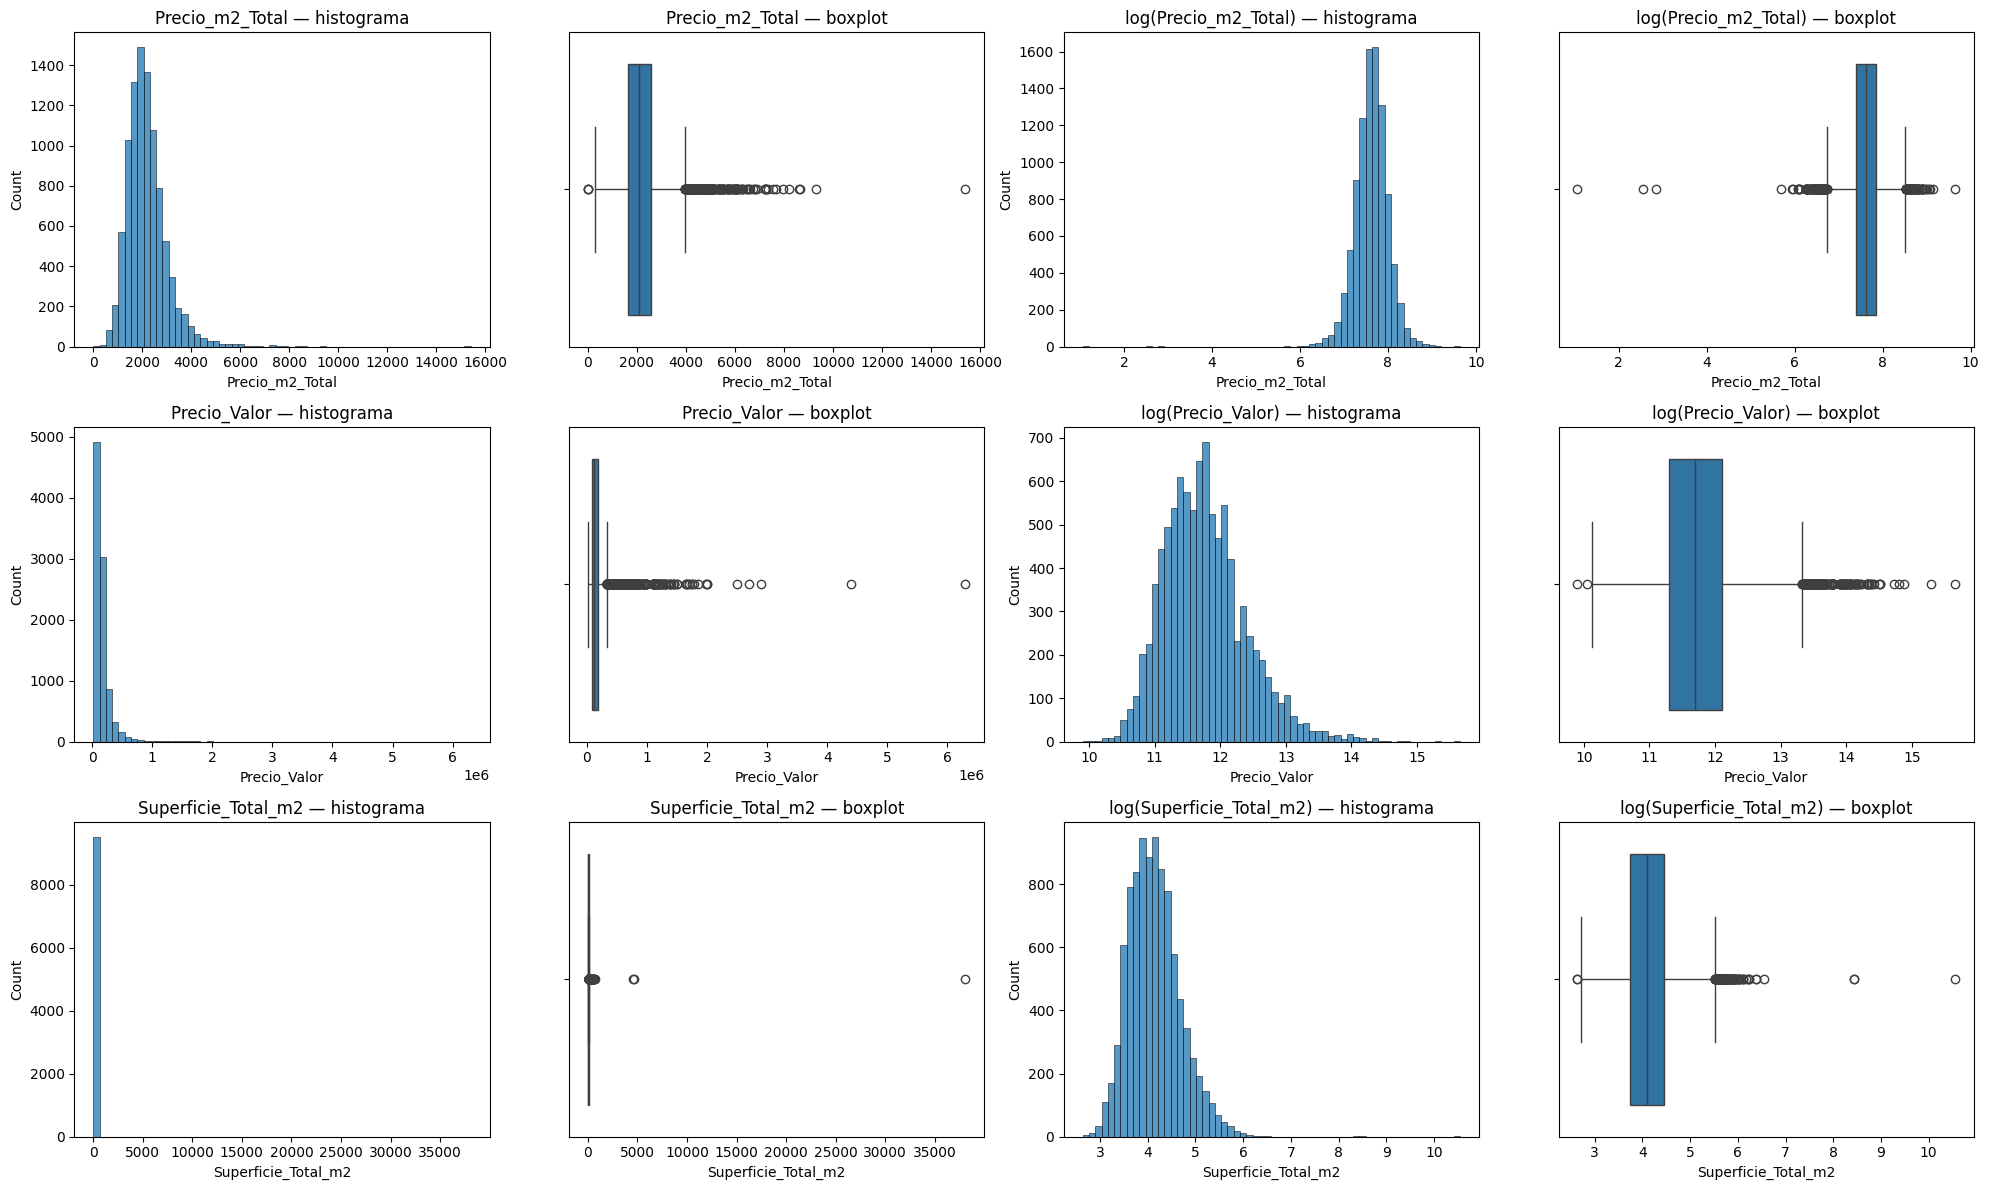

Tests de normalidad (H0: distribución normal):


Asimetría  Curtosis  p-valor Jarque-Bera  \
Variable            Escala                                                  
Precio_m2_Total     Original          1.93     12.26                  0.0   
                    Logarítmica      -1.17     16.94                  0.0   
Precio_Valor        Original          9.89    223.40                  0.0   
                    Logarítmica       0.77      1.18                  0.0   
Superficie_Total_m2 Original         91.64   8711.32                  0.0   
                    Logarítmica       0.79      3.10                  0.0   

                                   p-valor KS  
Variable            Escala                     
Precio_m2_Total     Original     7.090142e-53  
                    Logarítmica  2.577065e-08  
Precio_Valor        Original     0.000000e+00  
                    Logarítmica  7.752793e-27  
Superficie_Total_m2 Original     0.000000e+00  
                    Logarítmica  1.106131e-12

In [36]:
# 11.1 OUTLIERS — INSPECCIÓN VISUAL Y NORMALIDAD

VARS_OUTLIERS = ["Precio_m2_Total", "Precio_Valor", "Superficie_Total_m2"]

# Gráficos: histograma y boxplot, escala original y logarítmica
fig, axes = plt.subplots(len(VARS_OUTLIERS), 4, figsize=(20, 4 * len(VARS_OUTLIERS)))

for i, var in enumerate(VARS_OUTLIERS):
    x = df_limpio[var].dropna()
    log_x = np.log(x)

    sns.histplot(x, bins=60, ax=axes[i, 0])
    axes[i, 0].set_title(f"{var} — histograma")
    sns.boxplot(x=x, ax=axes[i, 1])
    axes[i, 1].set_title(f"{var} — boxplot")

    sns.histplot(log_x, bins=60, ax=axes[i, 2])
    axes[i, 2].set_title(f"log({var}) — histograma")
    sns.boxplot(x=log_x, ax=axes[i, 3])
    axes[i, 3].set_title(f"log({var}) — boxplot")

plt.tight_layout()
plt.show()

# Tests de normalidad
filas = []
for var in VARS_OUTLIERS:
    x = df_limpio[var].dropna()
    for escala, valores in [("Original", x), ("Logarítmica", np.log(x))]:
        z = (valores - valores.mean()) / valores.std()
        jb = stats.jarque_bera(valores)
        ks = stats.kstest(z, "norm")
        filas.append({
            "Variable": var, "Escala": escala,
            "Asimetría": round(stats.skew(valores), 2),
            "Curtosis": round(stats.kurtosis(valores), 2),
            "p-valor Jarque-Bera": jb.pvalue,
            "p-valor KS": ks.pvalue,
        })

print("Tests de normalidad (H0: distribución normal):")
display(pd.DataFrame(filas).set_index(["Variable", "Escala"]))

**Resultado.** En escala original las tres variables presentan una fuerte asimetría positiva, especialmente la superficie total (asimetría 91,6 y curtosis 8.711). Esa forma está determinada por unos pocos valores inverosímiles para un departamento: dos avisos cercanos a 4.700 m² y uno de 38.090 m². La transformación logarítmica reduce sustancialmente la asimetría, pero los tests rechazan la normalidad en todos los casos. Esto se debe en parte al tamaño de la muestra, que vuelve significativos desvíos menores, y en parte a colas pesadas generadas por pocos casos extremos. En el logaritmo del precio por m² se destacan tres observaciones con valores de entre USD 3 y USD 20 por m², incompatibles con el mercado de CABA, que probablemente corresponden a superficies mal cargadas.

Como las variables no son normales, las reglas basadas en el desvío estándar no pueden aplicarse en escala original. La detección se realiza después de una transformación Box-Cox.

### 11.2 Detección estadística

Cada variable se transforma con Box-Cox, que estima el parámetro λ que acerca la distribución a la normalidad (un λ cercano a 0 equivale a una transformación logarítmica). Sobre la variable transformada se aplican:

- **Regla de Tukey** con dos umbrales: 1,5 veces el rango intercuartílico (valor **atípico**) y 3 veces el rango intercuartílico (valor **extremo**). Con una muestra de este tamaño, el primer umbral también incluye observaciones genuinas de segmentos poco frecuentes, mientras que el segundo concentra los candidatos a error de carga.
- **z-score** mayor a 3 en valor absoluto, como criterio complementario.

Además, se aplica un criterio multivariado: la **distancia de Mahalanobis** sobre el precio por m², la superficie (ambas transformadas) y la cantidad de ambientes, con un umbral dado por el percentil 97,5 de una chi-cuadrado con 3 grados de libertad. Este criterio identifica combinaciones inusuales que no son extremas en ninguna variable por separado, como una unidad de pocos ambientes con una superficie muy grande. El precio total no se incluye porque es el producto del precio por m² y la superficie, y sería redundante.

In [37]:
# 11.2 OUTLIERS — DETECCIÓN ESTADÍSTICA

# Box-Cox + Tukey + z-score
resumen_bc = []
for var in VARS_OUTLIERS:
    transformada, lam = boxcox(df_limpio[var])
    transformada = pd.Series(transformada, index=df_limpio.index)
    aux[f"bc_{var}"] = transformada

    q1, q3 = transformada.quantile([0.25, 0.75])
    iqr = q3 - q1
    z = (transformada - transformada.mean()) / transformada.std()

    aux[f"atipico_{var}"] = (transformada < q1 - 1.5 * iqr) | (transformada > q3 + 1.5 * iqr)
    aux[f"extremo_{var}"] = (transformada < q1 - 3 * iqr) | (transformada > q3 + 3 * iqr)
    aux[f"z3_{var}"] = z.abs() > 3

    resumen_bc.append({
        "Variable": var,
        "Lambda Box-Cox": round(lam, 3),
        "Asimetría transformada": round(stats.skew(transformada), 2),
        "Atípicos Tukey 1,5 (bajos)": int((transformada < q1 - 1.5 * iqr).sum()),
        "Atípicos Tukey 1,5 (altos)": int((transformada > q3 + 1.5 * iqr).sum()),
        "Extremos Tukey 3": int(aux[f"extremo_{var}"].sum()),
        "|z| > 3": int(aux[f"z3_{var}"].sum()),
    })

print("Detección univariada sobre variables transformadas:")
display(pd.DataFrame(resumen_bc).set_index("Variable"))

# Mahalanobis
X = aux[["bc_Precio_m2_Total", "bc_Superficie_Total_m2", "Ambientes"]].values
diferencia = X - X.mean(axis=0)
inv_cov = np.linalg.inv(np.cov(X, rowvar=False))
aux["mahalanobis2"] = np.einsum("ij,jk,ik->i", diferencia, inv_cov, diferencia)

umbral_mahal = chi2.ppf(0.975, df=3)
aux["outlier_mahal"] = aux["mahalanobis2"] > umbral_mahal
print(f"\nMahalanobis: umbral chi² (97,5%, 3 gl) = {umbral_mahal:.2f}")
print("Outliers multivariados:", int(aux["outlier_mahal"].sum()))

# Coincidencia entre criterios
aux["extremo_univariado"] = aux[[f"extremo_{v}" for v in VARS_OUTLIERS]].any(axis=1)
print("\nCoincidencia entre extremos univariados (Tukey 3) y Mahalanobis:")
display(pd.crosstab(aux["extremo_univariado"], aux["outlier_mahal"], margins=True))

# Casos extremos para revisión contextual
cols_revision = ["ID", "Titulo", "Tipo_Propiedad_Original", "Barrio", "Ambientes",
                 "Superficie_Total_m2", "Superficie_Cubierta_m2", "Precio_Valor", "Precio_m2_Total"]

print("\nExtremos univariados (Tukey 3), ordenados por USD/m²:")
display(aux.loc[aux["extremo_univariado"], cols_revision].sort_values("Precio_m2_Total"))

Detección univariada sobre variables transformadas:


,Lambda Box-Cox,Asimetría transformada,"Atípicos Tukey 1,5 (bajos)","Atípicos Tukey 1,5 (altos)",Extremos Tukey 3,|z| > 3
Variable,,,,,,
Precio_m2_Total,0.254,0.10,79,127,9,88
Precio_Valor,-0.370,0.01,22,28,0,22
Superficie_Total_m2,-0.369,0.00,19,13,0,18



Mahalanobis: umbral chi² (97,5%, 3 gl) = 9.35
Outliers multivariados: 360

Coincidencia entre extremos univariados (Tukey 3) y Mahalanobis:


outlier_mahal,False,True,All
extremo_univariado,,,
False,9143,351,9494
True,0,9,9
All,9143,360,9503



Extremos univariados (Tukey 3), ordenados por USD/m²:


,ID,Titulo,Tipo_Propiedad_Original,Barrio,Ambientes,Superficie_Total_m2,Superficie_Cubierta_m2,Precio_Valor,Precio_m2_Total
2352,648268,Venta dpto 1 1/2 amb Almagro,departamento_estandar,Almagro,1,38090.00,33420.00,110000.0,2.89
105,658850,DEPARTAMENTO EN VENTA EN FLORES CAPITAL FEDERAL,departamento_estandar,Flores,1,4582.00,4582.00,59000.0,12.88
3954,639806,"VENTA DEPARTAMENTO 2 AMBIENTES, SAN CRISTOBAL",departamento_estandar,San Cristobal,2,4633.00,4633.00,80000.0,17.27
13758,559265,VENTA DEPARTAMENTO NUÑEZ CUATRO AMBIENTES EN T...,departamento_piso,Nuñez,4,225.00,198.00,1790000.0,7955.56
14973,532144,VENTA DEPTO 2AMB C/ COCHERA BAULERA FULL AMENI...,departamento_estandar,Belgrano,2,60.23,45.02,495000.0,8218.50
4689,636067,VENTA ESPECTACULAR PISO ALTO CHATEAU LIBERTADOR,departamento_piso,Nuñez,6,511.04,480.39,4400000.0,8609.89
16281,444264,VENTA DEPARTAMENTO 5 AMB + DEP TORRE BELLINI N...,departamento_semipiso,Nuñez,6,334.62,309.62,2900000.0,8666.55
9600,605137,EXCLUSIVO PISO ALTO EN TORRES DECO POLO,departamento_estandar,Las Cañitas,3,156.00,156.00,1450000.0,9294.87
14747,537642,PISO 34 -TERMINADO con materiales premium unicos,departamento_semipiso,Palermo,4,409.00,343.00,6300000.0,15403.42


### 11.3 Revisión contextual de los valores extremos

La regla de Tukey con 3 veces el rango intercuartílico identifica 9 valores extremos, todos en el precio por m², que forman dos grupos claramente diferenciados.

**Errores de carga en la superficie.** Tres avisos tienen precios por m² de entre USD 3 y USD 17 porque informan superficies de 4.582, 4.633 y 38.090 m² para unidades de uno o dos ambientes. Los precios publicados son normales para ese tipo de unidad, y las superficies parecen haber perdido el separador decimal (por ejemplo, 38.090 m² en lugar de 38,09 m²). Como la superficie real no puede confirmarse, no se corrige: se excluyen los avisos con superficie total superior a 1.000 m², un valor imposible para estas unidades.

**Segmento de lujo genuino.** Los seis extremos superiores (entre USD 7.956 y USD 15.403 por m²) son pisos y semipisos de entre 156 y 511 m² en Núñez, Las Cañitas y Palermo, en edificios reconocidos del segmento de alta gama. No son errores sino observaciones genuinas del segmento de súper lujo, por lo que se conservan. El único caso dudoso es un departamento de dos ambientes y 60 m² en Belgrano publicado a USD 495.000, que se conserva por no haber evidencia suficiente de error, pero queda marcado.

**Los valores atípicos bajos no se eliminan.** Con el umbral de 1,5 veces el rango intercuartílico, 79 avisos presentan precios por m² inusualmente bajos. Para el objetivo del proyecto, ese grupo es de interés central: es donde pueden encontrarse propiedades subvaluadas o que necesitan refacción. Eliminarlos como outliers descartaría precisamente las oportunidades que se busca identificar. Por eso los valores atípicos que no son errores comprobados se conservan y se marcan con indicadores, que permitirán analizarlos por separado. Además, el benchmark de comparables se calcula con la mediana, que es robusta frente a valores extremos.

Como los tres errores de superficie inflan la matriz de covarianza utilizada en la distancia de Mahalanobis, la detección se recalcula después de excluirlos.

In [38]:
# 11.3 EXCLUSIÓN DE ERRORES DE SUPERFICIE

UMBRAL_SUPERFICIE = 1000

mask_sup_imposible = df_limpio["Superficie_Total_m2"] > UMBRAL_SUPERFICIE
print("Avisos con superficie total mayor a 1.000 m²:")
display(df_limpio.loc[mask_sup_imposible, cols_revision])

df_limpio = excluir(
    df_limpio, mask_sup_imposible,
    paso="Outliers: superficie imposible",
    criterio=f"Superficie total mayor a {UMBRAL_SUPERFICIE} m² (error de carga, separador decimal perdido)",
    registro=registro,
)

Avisos con superficie total mayor a 1.000 m²:


,ID,Titulo,Tipo_Propiedad_Original,Barrio,Ambientes,Superficie_Total_m2,Superficie_Cubierta_m2,Precio_Valor,Precio_m2_Total
105,658850,DEPARTAMENTO EN VENTA EN FLORES CAPITAL FEDERAL,departamento_estandar,Flores,1,4582.0,4582.0,59000.0,12.88
2352,648268,Venta dpto 1 1/2 amb Almagro,departamento_estandar,Almagro,1,38090.0,33420.0,110000.0,2.89
3954,639806,"VENTA DEPARTAMENTO 2 AMBIENTES, SAN CRISTOBAL",departamento_estandar,San Cristobal,2,4633.0,4633.0,80000.0,17.27


In [39]:
# 11.4 DETECCIÓN RECALCULADA SOBRE LA BASE DEPURADA

det = detectar_outliers(df_limpio, VARS_OUTLIERS)

atipico_bajo = det[[f"atipico_bajo_{v}" for v in VARS_OUTLIERS]].any(axis=1)
atipico_alto = det[[f"atipico_alto_{v}" for v in VARS_OUTLIERS]].any(axis=1)

print("Atípicos bajos (Tukey 1,5, alguna variable):", int(atipico_bajo.sum()))
print("Atípicos altos (Tukey 1,5, alguna variable):", int(atipico_alto.sum()))
print("Outliers multivariados (Mahalanobis):", int(det["outlier_mahal"].sum()))

Atípicos bajos (Tukey 1,5, alguna variable): 129
Atípicos altos (Tukey 1,5, alguna variable): 120
Outliers multivariados (Mahalanobis): 379


In [40]:
# 11.4 (cont.) REVISIÓN DE LOS OUTLIERS MULTIVARIADOS

cols_mahal = ["ID", "Titulo", "Barrio", "Ambientes", "Superficie_Total_m2",
              "Superficie_Cubierta_m2", "Precio_Valor", "Precio_m2_Total"]

print("\nLos 25 avisos con mayor distancia de Mahalanobis:")
display(
    df_limpio[cols_mahal].assign(Mahalanobis2=det["mahalanobis2"].round(1))
    .loc[det["outlier_mahal"]].sort_values("Mahalanobis2", ascending=False).head(25)
)

print("\nOutliers multivariados según cantidad de ambientes:")
display(pd.crosstab(df_limpio["Ambientes"], det["outlier_mahal"], margins=True))


Los 25 avisos con mayor distancia de Mahalanobis:


,ID,Titulo,Barrio,Ambientes,Superficie_Total_m2,Superficie_Cubierta_m2,Precio_Valor,Precio_m2_Total,Mahalanobis2
2486,647627,VENTA DEPARTAMENTO PENTHOUSE 13 AMBIENTES RECO...,Barrio Norte,13,703.00,513.00,850000.0,1209.10,129.1
14889,535724,VENTA DEPTO EN DÚPLEX EN LIBERTADOR 336 DE 58...,Recoleta,12,587.39,549.36,2500000.0,4256.12,114.6
10542,597976,"VENTA Depto. 12 Amb. C/ PISCINA PRIVADA ""RETIRO""",Retiro,12,592.00,482.00,990000.0,1672.30,102.4
5111,633846,VENTA PISO 10 AMB. BALVANERA. APTO HOSTEL,Balvanera,10,161.00,160.00,145000.0,900.62,79.0
15489,510214,Piso Premium en Avenida Quintana y Ayacucho.,Recoleta,10,309.00,280.00,1150000.0,3721.68,70.5
14747,537642,PISO 34 -TERMINADO con materiales premium unicos,Palermo,4,409.00,343.00,6300000.0,15403.42,48.8
8295,614451,Venta DUPLEX SIN EXP Cochera CABALLLITO,Caballito,9,300.00,226.00,450000.0,1500.00,42.3
9964,602680,Venta Planta Libre Hecho a nuevo Microcentro,San Nicolás,1,243.00,243.00,299000.0,1230.45,41.7
15310,518660,Venta – Exclusivo Departamento Ateneo Splendid,Recoleta,9,400.00,400.00,1100000.0,2750.00,41.7
4323,637941,"Venta Penthouse 7 ambientes, piscina 3 cocheras",Belgrano,8,350.00,230.00,1980000.0,5657.14,38.7



Outliers multivariados según cantidad de ambientes:


outlier_mahal,False,True,All
Ambientes,,,
1,1459,68,1527
2,2725,47,2772
3,2958,63,3021
4,1655,71,1726
5,295,28,323
6,29,58,87
7,0,23,23
8,0,14,14
9,0,2,2


### 11.4 Revisión de los outliers multivariados

Después de excluir los tres errores de superficie, la distancia de Mahalanobis identifica 379 avisos (4% de la base). La tabla por cantidad de ambientes muestra que este criterio marca principalmente las unidades grandes: se identifican todas las unidades de siete o más ambientes y dos tercios de las de seis, contra entre 2% y 4% en las unidades de uno a cuatro ambientes. Esto se debe a que la cantidad de ambientes es una variable discreta con una cola larga, y sus pocos valores altos quedan alejados del centro de la distribución. Esto también refleja una limitación del método: la distancia de Mahalanobis supone una distribución aproximadamente normal multivariada, supuesto que no se cumple con una variable discreta y asimétrica como la cantidad de ambientes. Por eso este criterio se utiliza solo para marcar casos a revisar y no para excluirlos.

La revisión de los 25 casos más alejados confirma que se trata mayormente de **segmentos genuinos poco frecuentes**: penthouses, dúplex y pisos de lujo de gran superficie, y también unidades a reciclar con precios por m² muy bajos, que son candidatas a oportunidades de flipping. Unos pocos casos son dudosos: avisos que sugieren un uso no residencial (apto hostel, planta libre, unidad divisible para oficina) y avisos cuya superficie no es coherente con el resto de la publicación. Como no hay evidencia suficiente para considerarlos errores, no se excluyen.

### 11.5 Tratamiento
Los criterios de detección se calcularon en los pasos 11.2 y 11.4 sobre variables auxiliares, sin modificar la base. En este paso, los resultados de la detección recalculada (11.4) se incorporan a la base limpia como indicadores.

No se realizan más exclusiones. Los valores atípicos se conservan y se identifican con cuatro indicadores:

- `Flag_Atipico_Bajo` y `Flag_Atipico_Alto`: valores fuera de 1,5 veces el rango intercuartílico en alguna de las variables analizadas (en la escala Box-Cox).
- `Flag_Extremo`: valores fuera de 3 veces el rango intercuartílico.
- `Flag_Outlier_Multivariado`: combinaciones inusuales según la distancia de Mahalanobis.

Estos indicadores tienen un uso concreto en el resto del proyecto: el benchmark de comparables se calcula con la mediana, que es robusta frente a estos valores, y en el ranking de oportunidades toda propiedad marcada se revisará manualmente antes de recomendarla, ya que un precio por m² inusualmente bajo puede ser tanto una oportunidad como un error de carga.

Cabe aclarar que la detección se realizó sobre la distribución del conjunto de la base. Como el precio por m² varía fuertemente entre barrios y tipos de unidad, un valor normal en una zona puede ser atípico en otra. La evaluación contextual de cada propiedad frente a su propio segmento no corresponde a esta etapa: se realizará mediante el gap de subvaluación, que compara el precio de cada aviso con el benchmark de propiedades comparables.

Además, la revisión muestra que en las unidades con mucha superficie descubierta el precio por m² calculado sobre la superficie total subestima el valor de la unidad. Este punto se tendrá en cuenta al definir la superficie de referencia para el benchmark de comparables.

In [41]:
# 11.5 INDICADORES DE OUTLIERS

df_limpio["Flag_Atipico_Bajo"] = False
df_limpio = modificar(
    df_limpio, atipico_bajo, "Flag_Atipico_Bajo", True,
    paso="Marca de outliers: atípico bajo",
    criterio="Debajo de Q1 − 1,5 IQR (Box-Cox) en USD/m², precio o superficie",
    registro=registro,
)

df_limpio["Flag_Atipico_Alto"] = False
df_limpio = modificar(
    df_limpio, atipico_alto, "Flag_Atipico_Alto", True,
    paso="Marca de outliers: atípico alto",
    criterio="Encima de Q3 + 1,5 IQR (Box-Cox) en USD/m², precio o superficie",
    registro=registro,
)

df_limpio["Flag_Extremo"] = False
df_limpio = modificar(
    df_limpio, det[[f"extremo_{v}" for v in VARS_OUTLIERS]].any(axis=1), "Flag_Extremo", True,
    paso="Marca de outliers: extremo",
    criterio="Fuera de 3 IQR (Box-Cox) en USD/m², precio o superficie",
    registro=registro,
)

df_limpio["Flag_Outlier_Multivariado"] = False
df_limpio = modificar(
    df_limpio, det["outlier_mahal"], "Flag_Outlier_Multivariado", True,
    paso="Marca de outliers: multivariado",
    criterio="Distancia de Mahalanobis² mayor al percentil 97,5 de chi² con 3 gl",
    registro=registro,
)

print("Avisos con al menos una marca de outlier:",
      int(df_limpio[["Flag_Atipico_Bajo", "Flag_Atipico_Alto",
                     "Flag_Extremo", "Flag_Outlier_Multivariado"]].any(axis=1).sum()))

display(tabla_registro(registro))

Avisos con al menos una marca de outlier: 447


,Paso,Tipo,Criterio,Registros_afectados,Filas_antes,Filas_despues
0,Alcance: tipología,Exclusión,Se excluyen tipologías que no son departamento...,5358,17023,11665
1,Error de carga: PH,Exclusión,El título indica PH y el texto lo confirma con...,53,11665,11612
2,Alcance: stock usado,Exclusión,"Pozo, preventa, en construcción o a estrenar (...",1963,11612,9649
3,Valores de relleno: expensas,Modificación (Expensas),Expensas = 0 sin mención de 'sin expensas' → d...,1013,9649,9649
4,Valores de relleno: antigüedad,Modificación (Antiguedad),Antigüedad = 0 en un departamento usado → dato...,287,9649,9649
5,Valor imposible: superficie cubierta,Modificación (Superficie_Cubierta_m2),Superficie cubierta = 0,1,9649,9649
6,Valor imposible: superficie cubierta,Modificación (Precio_m2_Cubierto),USD/m² cubierto calculado sobre superficie cub...,1,9649,9649
7,Unificación de criterio: dormitorios,Modificación (Dormitorios),Unidades de 1 ambiente → 0 dormitorios,536,9649,9649
8,Marca de calidad: ambientes,Modificación (Flag_Ambientes_Dudoso),La cantidad de ambientes declarada en el títul...,275,9649,9649
9,Marca de calidad: dormitorios,Modificación (Flag_Dormitorios_Inconsistente),Dormitorios >= Ambientes en unidades de 2 o má...,163,9649,9649


**Resultado.** El tratamiento de outliers excluyó únicamente tres avisos con superficies imposibles, y la base queda en 9.500 departamentos. Otros 447 avisos (4,7%) tienen al menos una marca de valor atípico: 129 con valores inusualmente bajos, 120 con valores inusualmente altos y 379 con combinaciones inusuales según la distancia de Mahalanobis (un mismo aviso puede tener más de una marca). Después de excluir los errores de superficie, solo tres avisos permanecen como valores extremos. Estos avisos se conservan en la base porque representan segmentos genuinos del mercado o posibles oportunidades, y los indicadores permitirán tratarlos con cautela en las etapas siguientes.

## 12. Cierre: base limpia y exportación

Se resume el recorrido completo de la limpieza a partir del registro de pasos, se hace un control final de calidad sobre la base resultante y se exportan dos archivos a `data/processed/`:

- `remax_deptos_limpio.csv`: base analítica de departamentos usados en venta, que será el insumo del notebook de ingeniería de variables y KPIs.
- `registro_limpieza.csv`: registro de cada exclusión y modificación aplicada, con su criterio y la cantidad de registros afectados.

Base raw: 17,023 avisos  →  Base limpia: 9,500 avisos (55.8% de la extracción original)



,Paso,Criterio,Registros_afectados,Filas_despues,% sobre la base raw
0,Alcance: tipología,Se excluyen tipologías que no son departamento...,5358,11665,31.48
1,Error de carga: PH,El título indica PH y el texto lo confirma con...,53,11612,0.31
2,Alcance: stock usado,"Pozo, preventa, en construcción o a estrenar (...",1963,9649,11.53
3,Duplicados,Misma propiedad publicada más de una vez (mism...,132,9517,0.78
4,Excepciones manuales (limpieza),Exclusiones documentadas en excepciones_manual...,12,9505,0.07
5,Normalización: moneda del precio,Precio en pesos con valor incompatible con una...,2,9503,0.01
6,Outliers: superficie imposible,Superficie total mayor a 1000 m² (error de car...,3,9500,0.02


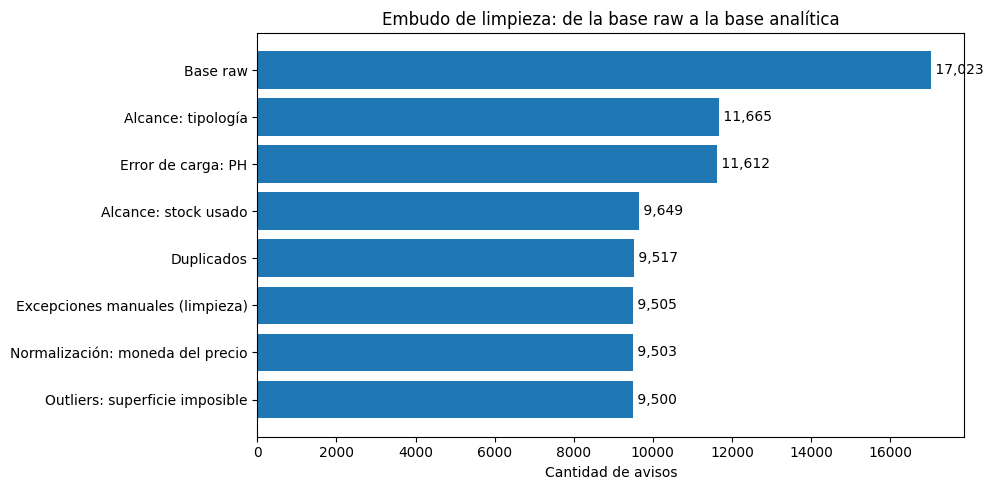

In [42]:
# 12. CIERRE

# 12.1 Embudo de exclusiones
registro_df = tabla_registro(registro)

exclusiones = registro_df.loc[registro_df["Tipo"] == "Exclusión",
                              ["Paso", "Criterio", "Registros_afectados", "Filas_despues"]].copy()
exclusiones["% sobre la base raw"] = (exclusiones["Registros_afectados"] / len(df) * 100).round(2)

print(f"Base raw: {len(df):,} avisos  →  Base limpia: {len(df_limpio):,} avisos "
      f"({len(df_limpio) / len(df) * 100:.1f}% de la extracción original)\n")
display(exclusiones.reset_index(drop=True))

etapas = ["Base raw"] + exclusiones["Paso"].tolist()
filas = [len(df)] + exclusiones["Filas_despues"].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(etapas[::-1], filas[::-1])
for i, valor in enumerate(filas[::-1]):
    ax.text(valor, i, f" {valor:,}", va="center")
ax.set_xlabel("Cantidad de avisos")
ax.set_title("Embudo de limpieza: de la base raw a la base analítica")
plt.tight_layout()
plt.show()

In [43]:
# 12.2 Control final de calidad
print("Dimensiones finales:", df_limpio.shape)
print("IDs duplicados:", int(df_limpio["ID"].duplicated().sum()))

print("\nReglas de consistencia (los casos restantes están marcados con indicadores):")
display(auditar_reglas(df_limpio))

print("Faltantes restantes:")
calidad_final = resumen_calidad(df_limpio)
display(calidad_final[calidad_final["Nulos"] > 0])

Dimensiones finales: (9500, 41)
IDs duplicados: 0

Reglas de consistencia (los casos restantes están marcados con indicadores):


,Casos
Regla,
Cubierta > Total,0
Superficie total <= 0,0
Precio <= 0,0
Ambientes = 0,0
Dormitorios >= Ambientes,154
Antigüedad negativa,0
USD/m² informado != calculado (>1%),0


Faltantes restantes:


,Tipo,Nulos,Nulos_%,Unicos
Fecha_Publicacion,float64,9500,100.00,0
Amenities,object,1642,17.28,6913
Expensas,float64,982,10.34,1392
Ambientes_Titulo,float64,619,6.52,12
Antiguedad,float64,322,3.39,121
Descripcion,object,54,0.57,9430
Apto_Credito,object,54,0.57,2
Precio_m2_Cubierto,float64,1,0.01,7822
Superficie_Cubierta_m2,float64,1,0.01,4087
Moneda_Expensas,object,1,0.01,2


In [44]:
# 12.3 Variables agregadas durante la limpieza
columnas_nuevas = [c for c in df_limpio.columns if c not in df.columns]
print("Variables agregadas en la limpieza:")
for c in columnas_nuevas:
    print("  -", c)

Variables agregadas en la limpieza:
  - Tipo_Propiedad_Original
  - Ambientes_Titulo
  - Flag_Ambientes_Dudoso
  - Flag_Dormitorios_Inconsistente
  - Flag_Posible_Republicacion
  - Expensas_Informadas
  - Antiguedad_Informada
  - Amenities_Informadas
  - Flag_Atipico_Bajo
  - Flag_Atipico_Alto
  - Flag_Extremo
  - Flag_Outlier_Multivariado


In [45]:
# 12.4 Exportación
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

ruta_base = PROCESSED_DIR / "remax_deptos_limpio.csv"
ruta_registro = PROCESSED_DIR / "registro_limpieza.csv"

df_limpio.to_csv(ruta_base, index=False)
registro_df.to_csv(ruta_registro, index=False)

print(f"\nExportado: {ruta_base} ({ruta_base.stat().st_size / 1e6:.1f} MB)")
print(f"Exportado: {ruta_registro}")


Exportado: data/processed/remax_deptos_limpio.csv (21.2 MB)
Exportado: data/processed/registro_limpieza.csv


## Conclusiones de la limpieza

A partir de los 17.023 avisos de la extracción raw se construyó una base analítica de **9.500 departamentos usados en venta** en CABA (55,8% de la extracción original). La mayor parte de la reducción responde a la definición del alcance y no a problemas de calidad: se excluyeron 5.358 avisos de otras tipologías, 53 PH clasificados como departamento y 1.963 propiedades nuevas o en desarrollo. Por problemas de calidad se excluyeron 132 duplicados, 11 ventas en bloque y un alquiler (registrados como excepciones manuales), 2 avisos con precio en pesos y 3 con superficies imposibles.

El criterio general fue conservador: **no se eliminó ningún valor por el solo hecho de ser extremo**. Los valores imposibles o de relleno se reemplazaron por faltantes, y los casos dudosos se conservaron con indicadores de calidad (ambientes dudosos, dormitorios inconsistentes, posibles republicaciones y valores atípicos). Este criterio es especialmente relevante para el objetivo del proyecto, porque los precios por m² inusualmente bajos pueden corresponder justamente a las propiedades subvaluadas o a refaccionar que se busca identificar.

Los faltantes no se imputaron en la base limpia, porque el diagnóstico mostró que ninguno es completamente aleatorio. Las expensas faltan con mayor frecuencia en las unidades más caras, y la antigüedad, en unidades probablemente recientes. Imputarlas con un valor central habría introducido sesgos. Su tratamiento se define en la etapa de ingeniería de variables, según el uso de cada variable.

Quedan dos tareas para la etapa siguiente: asignar el barrio oficial a partir de las coordenadas (las etiquetas de la fuente incluyen subzonas informales y hay coordenadas fuera de CABA) y definir la superficie de referencia para el precio por m², dado que la superficie descubierta distorsiona el indicador calculado sobre la superficie total.